# Remove noise from BTC prices and pass it in a DNN-HMM

We will use the Binance API to get BTC prices. We will use the following methods to de noise our data:
1) Exponential Moving Average (EMA)
2) Wavelet transformation (db4, MODWT)
3) Singular Spectrum Analysis (SSA)

We will evaluate multiple DNNHMM models for different wavelets and for different SSA, EMA and RSI periods. Our DNNHMM will only receive the RSI values as input for regime detection.

We will also evaluate our models for smaller time frames.

In [1]:
import requests
import pandas as pd
import time
from datetime import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score
import pywt
from scipy import signal
from tqdm import tqdm
import os
sns.set()

def get_btc_close_prices(start_date, end_date, interval="1d"):
    """
    Download BTC/USDT historical close prices from Binance API with customizable frequency
    
    Args:
        start_date (str): Start date in format 'YYYY-MM-DD'
        end_date (str): End date in format 'YYYY-MM-DD'
        interval (str, optional): Data frequency. Valid options:
            - Minutes: '1m', '3m', '5m', '15m', '30m'
            - Hours: '1h', '2h', '4h', '6h', '8h', '12h'
            - Days: '1d', '3d'
            - Weeks: '1w'
            - Months: '1M'
            Default is '1d' (daily data)
        
    Returns:
        pandas.Series: Series containing the historical close prices
    """
    # Validate interval parameter
    valid_intervals = ['1m', '3m', '5m', '15m', '30m', '1h', '2h', '4h', '6h', '8h', '12h', '1d', '3d', '1w', '1M']
    if interval not in valid_intervals:
        raise ValueError(f"Invalid interval: {interval}. Valid options are: {', '.join(valid_intervals)}")
    
    # Determine appropriate time window based on interval
    # For higher frequency data (especially minutes), we may need to split requests into smaller time chunks
    time_chunk_days = 1000  # Default chunk size in days (for daily data)
    
    if interval.endswith('m'):
        # For minute data, reduce time chunk size significantly
        # 1000 minutes would be less than a day, so we'll use chunks of ~7 days for minute data
        time_chunk_days = 7
    elif interval.endswith('h'):
        # For hourly data, reduce time chunk size moderately
        # 1000 hours would be ~41 days, so we'll use chunks of ~30 days for hourly data
        time_chunk_days = 30
    
    # Convert dates to milliseconds timestamp
    start_ts = int(datetime.strptime(start_date, '%Y-%m-%d').timestamp() * 1000)
    end_ts = int(datetime.strptime(end_date, '%Y-%m-%d').timestamp() * 1000)
    
    # Binance API endpoint for historical klines (candlestick) data
    base_url = "https://api.binance.com/api/v3/klines"
    
    # Parameters for the API request
    symbol = "BTCUSDT"
    limit = 1000  # Maximum number of data points per request
    
    # Calculate total time range in milliseconds
    total_time_ms = end_ts - start_ts
    
    # Calculate time chunk size in milliseconds
    time_chunk_ms = time_chunk_days * 24 * 60 * 60 * 1000
    
    # Calculate number of iterations needed
    iterations = math.ceil(total_time_ms / time_chunk_ms)
    
    all_data = []
    current_start_ts = start_ts
    
    print(f"Downloading BTC close prices from {start_date} to {end_date} with {interval} interval...")
    
    # Iterate through time chunks to get all data
    for i in range(iterations):
        current_end_ts = min(current_start_ts + time_chunk_ms, end_ts)
        
        # Set parameters for the current request
        params = {
            'symbol': symbol,
            'interval': interval,
            'startTime': current_start_ts,
            'endTime': current_end_ts,
            'limit': limit
        }
        
        # Make the API request
        response = requests.get(base_url, params=params)
        
        # Check if request was successful
        if response.status_code == 200:
            data = response.json()
            
            # Extract only timestamp and close price
            for candle in data:
                all_data.append([candle[0], candle[4]])  # candle[0]=timestamp, candle[4]=close
            
            # Update the start timestamp for the next iteration
            current_start_ts = current_end_ts + 1
            
            # Respect Binance API rate limits
            time.sleep(0.1)
            
            print(f"Progress: {i+1}/{iterations} chunks downloaded - {len(all_data)} data points so far")
        else:
            print(f"Error: {response.status_code}, {response.text}")
            # If we hit an error, wait a bit longer before retrying
            time.sleep(1)
            # Retry the same chunk with a smaller window if possible
            if time_chunk_ms > 24 * 60 * 60 * 1000:  # If chunk is larger than 1 day
                time_chunk_ms = time_chunk_ms // 2
                iterations = math.ceil(total_time_ms / time_chunk_ms)
                print(f"Reducing time chunk size and retrying. New chunk size: {time_chunk_ms/(24*60*60*1000):.1f} days")
                current_start_ts = start_ts  # Reset to beginning
                all_data = []  # Reset collected data
                i = -1  # Reset iteration counter (will be incremented to 0 at start of next loop)
                continue
            else:
                break
    
    if not all_data:
        raise ValueError("No data retrieved from API. Check parameters and try again.")
    
    # Create a DataFrame with only timestamp and close price
    df = pd.DataFrame(all_data, columns=['timestamp', 'close'])
    
    # Convert timestamp to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    
    # Convert close prices to float
    df['close'] = df['close'].astype(float)
    
    # Set timestamp as index
    df = df.set_index('timestamp')
    
    # Sort index to ensure data is chronological
    df = df.sort_index()
    
    # Return only the close prices as a Series
    return df

# raw_data = get_btc_close_prices('2018-01-01', '2024-12-31') # daily data
raw_data = get_btc_close_prices('2018-01-01', '2024-12-31', interval='1d') # hourly


raw_data.head()

Progress: 1/3 chunks downloaded - 1000 data points so far
Progress: 2/3 chunks downloaded - 2000 data points so far
Progress: 3/3 chunks downloaded - 2556 data points so far


,close
timestamp,
2018-01-01,13380.00
2018-01-02,14675.11
2018-01-03,14919.51
2018-01-04,15059.54
2018-01-05,16960.39


#### EMA + RSI periods
EMA 20 + RSI 14
Why: The 20-day EMA is a popular intermediate smoother—it reduces daily noise while staying responsive to trends. Pairing it with the classic 14-period RSI (Wilder’s default) balances noise reduction with momentum detection.

Use Case: Daily charts for swing trading stocks or forex. It’s a solid middle ground for most markets.

EMA 50 + RSI 20
Why: A 50-day EMA is a strong smoother, often used for longer-term trends, and a 20-period RSI further filters out short-term wiggles. This combo prioritizes clarity over speed.

Use Case: Longer-term investing or trading less volatile assets (e.g., large-cap stocks, indices) on daily or weekly charts.

EMA 10 + RSI 10
Why: The 10-day EMA keeps things fairly responsive while cutting some noise, and a 10-period RSI matches its pace for quicker signals with moderate smoothing.

Use Case: Shorter-term trading (e.g., intraday on 1-hour charts) or more volatile assets like crypto or small-cap stocks.

EMA 30 + RSI 25
Why: A 30-day EMA smooths well without excessive lag, and a 25-period RSI is less common but strikes a nice balance between noise reduction and trend sensitivity.

Use Case: A compromise for swing traders wanting smoother signals than EMA 20/RSI 14 but faster response than EMA 50/RSI 20.

#### Wavelet Transformation
It seems likely that for denoising Bitcoin prices, common mother wavelets include Haar, Daubechies (db2, db4, db6), and Biorthogonal (bior1.3, bior2.2), suitable for capturing price volatility.

#### SSA periods
The evidence leans toward choosing SSA window lengths based on expected cycles, such as 5, 10, 20, 50, 100, and 200 days for daily data, adjusted for data frequency.

In [2]:
# Function to calculate RSI
def calculate_rsi(series, period=14):
    """
    Calculate Relative Strength Index (RSI) for a price series.
    
    Args:
        series (pandas.Series): Price series
        period (int): RSI period
        
    Returns:
        pandas.Series: RSI values
    """
    # Calculate price changes
    delta = series.diff()
    
    # Separate gains and losses
    gains = delta.where(delta > 0, 0)
    losses = -delta.where(delta < 0, 0)
    
    # Calculate average gains and losses
    avg_gains = gains.rolling(window=period).mean()
    avg_losses = losses.rolling(window=period).mean()
    
    # Calculate RS (Relative Strength)
    rs = avg_gains / avg_losses
    
    # Calculate RSI
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

# Function to calculate EMA
def calculate_ema(series, period):
    """
    Calculate Exponential Moving Average (EMA) for a price series.
    
    Args:
        series (pandas.Series): Price series
        period (int): EMA period
        
    Returns:
        pandas.Series: EMA values
    """
    return series.ewm(span=period, adjust=False).mean()

# Function for wavelet denoising
def wavelet_denoise(series, wavelet='db4', level=1):
    """
    Apply wavelet denoising to a price series.
    
    Args:
        series (pandas.Series): Price series
        wavelet (str): Wavelet type ('haar', 'db4', etc.)
        level (int): Decomposition level
        
    Returns:
        pandas.Series: Denoised series
    """
    # Convert to numpy array
    data = series.values
    
    # Perform wavelet decomposition
    coeffs = pywt.wavedec(data, wavelet, level=level)
    
    # Apply thresholding to detail coefficients
    for i in range(1, len(coeffs)):
        # Calculate threshold (using VisuShrink/universal threshold)
        threshold = np.sqrt(2 * np.log(len(data))) * np.std(coeffs[i]) / np.sqrt(len(coeffs[i]))
        
        # Apply soft thresholding
        coeffs[i] = pywt.threshold(coeffs[i], threshold, mode='soft')
    
    # Reconstruct signal
    denoised_data = pywt.waverec(coeffs, wavelet)
    
    # Ensure same length as original (reconstruction might alter length slightly)
    denoised_data = denoised_data[:len(data)]
    
    # Convert back to pandas Series with same index
    return pd.Series(denoised_data, index=series.index)

# Function for Singular Spectrum Analysis (SSA) denoising
def ssa_denoise(series, window_length, components=None):
    """
    Apply Singular Spectrum Analysis (SSA) for denoising a price series.
    
    Args:
        series (pandas.Series): Price series
        window_length (int): Window length for SSA
        components (list, optional): List of components to reconstruct signal (e.g., [0, 1])
                                     If None, first half of components are used
        
    Returns:
        pandas.Series: Denoised series
    """
    # Convert to numpy array
    data = series.values
    N = len(data)
    
    # Create trajectory matrix (embedding)
    K = N - window_length + 1
    trajectory_matrix = np.zeros((window_length, K))
    
    for i in range(K):
        trajectory_matrix[:, i] = data[i:i+window_length]
    
    # Singular Value Decomposition
    U, sigma, Vt = np.linalg.svd(trajectory_matrix, full_matrices=False)
    
    # Determine components to use for reconstruction
    if components is None:
        components = list(range(window_length // 2))
    
    # Reconstruct signal using selected components
    reconstructed = np.zeros_like(trajectory_matrix)
    
    for i in components:
        reconstructed += sigma[i] * np.outer(U[:, i], Vt[i, :])
    
    # Diagonal averaging to convert reconstructed matrix back to a time series
    denoised_data = np.zeros(N)
    count = np.zeros(N)
    
    for i in range(window_length):
        for j in range(K):
            denoised_data[i+j] += reconstructed[i, j]
            count[i+j] += 1
    
    denoised_data /= count
    
    # Convert back to pandas Series with same index
    return pd.Series(denoised_data, index=series.index)

# Main execution
if __name__ == "__main__":
    # Download BTC close prices (adjust dates as needed)
    # raw_data = get_btc_close_prices('2018-01-01', '2024-12-31', interval='1h')
    
    # Create a dictionary to store all denoised series and original
    price_data = {'original': raw_data['close']}
    
    # Apply EMA denoising with different periods
    ema_periods = [10, 20, 30, 50]
    for period in ema_periods:
        price_data[f'ema_{period}'] = calculate_ema(raw_data['close'], period)
    
    # Apply wavelet denoising with different mother wavelets
    wavelets = ['haar', 'db2', 'db4', 'db6', 'bior1.3', 'bior2.2']
    for wavelet in wavelets:
        price_data[f'wavelet_{wavelet}'] = wavelet_denoise(raw_data['close'], wavelet=wavelet, level=3)
    
    # Apply SSA denoising with different window lengths
    ssa_windows = [5, 10, 20, 50, 100, 200]
    for window in ssa_windows:
        # Only apply SSA if we have enough data points
        if len(raw_data) >= window * 2:
            price_data[f'ssa_{window}'] = ssa_denoise(raw_data['close'], window_length=window)
    
    # Create DataFrame for RSI calculations
    rsi_data = pd.DataFrame(index=raw_data.index)
    
    # Calculate RSI for original data and each denoised series with different periods
    rsi_periods = [10, 14, 20, 25]
    
    # For EMA denoised data (specified combinations)
    ema_rsi_combos = {
        'ema_20': 14,  # EMA 20 + RSI 14
        'ema_50': 20,  # EMA 50 + RSI 20
        'ema_10': 10,  # EMA 10 + RSI 10
        'ema_30': 25   # EMA 30 + RSI 25
    }
    
    for ema_key, rsi_period in ema_rsi_combos.items():
        col_name = f"{ema_key}_rsi_{rsi_period}"
        rsi_data[col_name] = calculate_rsi(price_data[ema_key], period=rsi_period)
    
    # For wavelet denoised data
    for wavelet in wavelets:
        for period in rsi_periods:
            col_name = f"wavelet_{wavelet}_rsi_{period}"
            rsi_data[col_name] = calculate_rsi(price_data[f'wavelet_{wavelet}'], period=period)
    
    # For SSA denoised data
    for window in ssa_windows:
        # Only process if the SSA was calculated (enough data points)
        if f'ssa_{window}' in price_data:
            for period in rsi_periods:
                col_name = f"ssa_{window}_rsi_{period}"
                rsi_data[col_name] = calculate_rsi(price_data[f'ssa_{window}'], period=period)
    
    # Add RSI for original (non-denoised) data as reference
    for period in rsi_periods:
        rsi_data[f'original_rsi_{period}'] = calculate_rsi(price_data['original'], period=period)
    
    # Drop NA values
    rsi_data = rsi_data.dropna()
    
    # Basic statistics of RSI data
    print("RSI DataFrame Shape:", rsi_data.shape)
    print("\nRSI Columns:")
    for col in rsi_data.columns:
        print(f"- {col}")
    
    print("\nRSI Basic Statistics:")
    print(rsi_data.describe().T[['mean', 'std', 'min', 'max']])
    
    # Example: Saving to CSV
    rsi_data.to_csv('btc_rsi_indicators.csv')

RSI DataFrame Shape: (2532, 56)

RSI Columns:
- ema_20_rsi_14
- ema_50_rsi_20
- ema_10_rsi_10
- ema_30_rsi_25
- wavelet_haar_rsi_10
- wavelet_haar_rsi_14
- wavelet_haar_rsi_20
- wavelet_haar_rsi_25
- wavelet_db2_rsi_10
- wavelet_db2_rsi_14
- wavelet_db2_rsi_20
- wavelet_db2_rsi_25
- wavelet_db4_rsi_10
- wavelet_db4_rsi_14
- wavelet_db4_rsi_20
- wavelet_db4_rsi_25
- wavelet_db6_rsi_10
- wavelet_db6_rsi_14
- wavelet_db6_rsi_20
- wavelet_db6_rsi_25
- wavelet_bior1.3_rsi_10
- wavelet_bior1.3_rsi_14
- wavelet_bior1.3_rsi_20
- wavelet_bior1.3_rsi_25
- wavelet_bior2.2_rsi_10
- wavelet_bior2.2_rsi_14
- wavelet_bior2.2_rsi_20
- wavelet_bior2.2_rsi_25
- ssa_5_rsi_10
- ssa_5_rsi_14
- ssa_5_rsi_20
- ssa_5_rsi_25
- ssa_10_rsi_10
- ssa_10_rsi_14
- ssa_10_rsi_20
- ssa_10_rsi_25
- ssa_20_rsi_10
- ssa_20_rsi_14
- ssa_20_rsi_20
- ssa_20_rsi_25
- ssa_50_rsi_10
- ssa_50_rsi_14
- ssa_50_rsi_20
- ssa_50_rsi_25
- ssa_100_rsi_10
- ssa_100_rsi_14
- ssa_100_rsi_20
- ssa_100_rsi_25
- ssa_200_rsi_10
- ssa_200_rsi

### Load data and run DNN-HMM for every column.

In [3]:
price = raw_data.iloc[24:,:]
price.to_csv('1h_btc.csv')
train_size = int(len(rsi_data) * 0.8)

train_rsi = rsi_data.iloc[:train_size,:]
train_rsi = train_rsi[['ema_50_rsi_20', 'original_rsi_20']] # For retesting
test_rsi = rsi_data.iloc[train_size:,:]
test_rsi = test_rsi[['ema_50_rsi_20', 'original_rsi_20']] # For retesting
train_price = price.iloc[:train_size,:]
test_price = price.iloc[train_size:,:]

In [4]:
train_rsi.head()

,ema_50_rsi_20,original_rsi_20
timestamp,,
2018-01-25,25.582513,29.519988
2018-01-26,15.903253,28.792563
2018-01-27,8.668275,32.849687
2018-01-28,5.389510,38.122849
2018-01-29,3.758120,37.747844


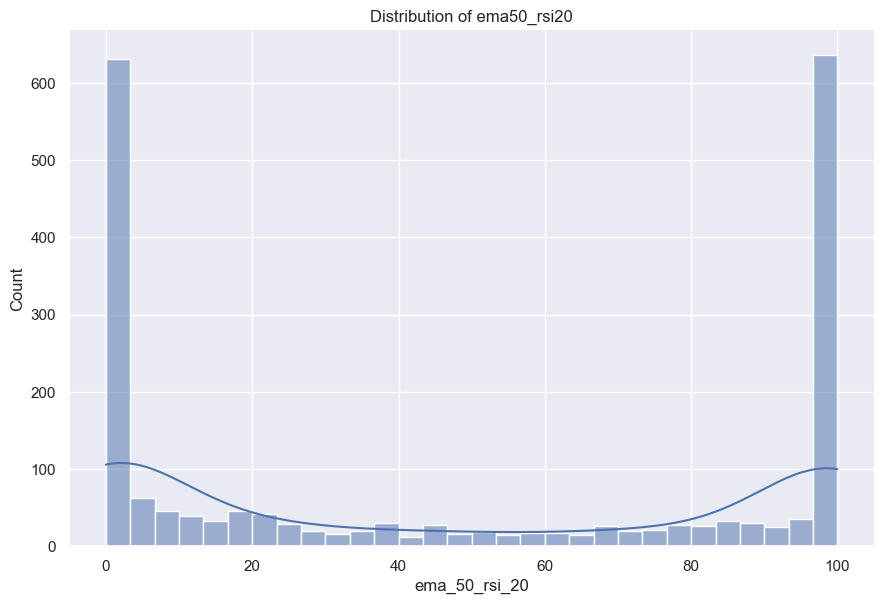

In [5]:
sns.displot(train_rsi['ema_50_rsi_20'], kind="hist", bins=30, kde=True, height=6, aspect=1.5)
plt.title("Distribution of ema50_rsi20")
plt.show()

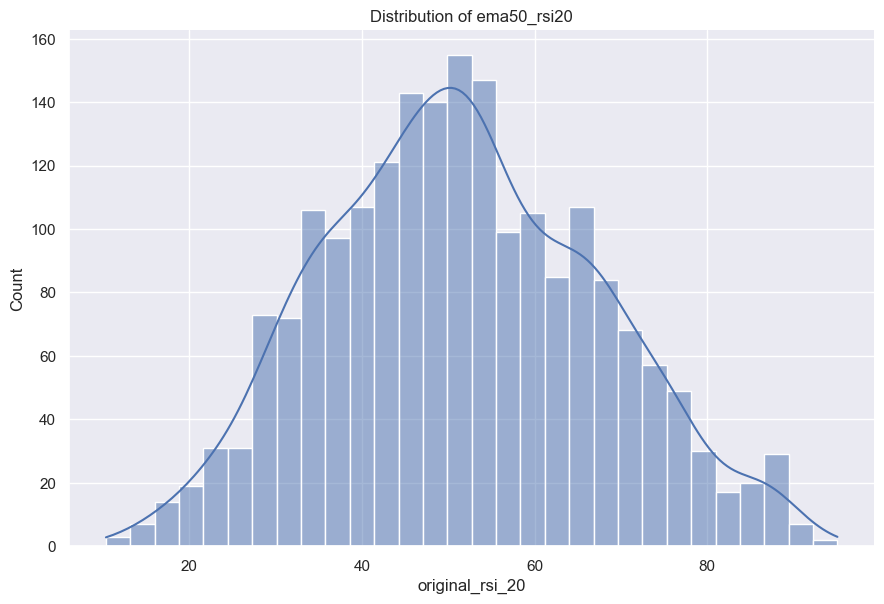

In [6]:
sns.displot(train_rsi['original_rsi_20'], kind="hist", bins=30, kde=True, height=6, aspect=1.5)
plt.title("Distribution of ema50_rsi20")
plt.show()

In [7]:
# train_rsi_test = train_rsi.iloc[:,1:2]
# test_rsi_test = test_rsi.iloc[:,1:2]

## Using 
# test_rsi_test = test_rsi.loc["ema_50_rsi_20"]
# # test_rsi_test = test_rsi.loc["ema_50_rsi_20"]

### DNN HMM model

In [8]:
# Create output directory for saved figures
os.makedirs("dnn_hmm_output", exist_ok=True)

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("DNN-HMM Analysis for Bitcoin RSI Indicators")
print("=" * 60)

# Define Feature Extractor (Neural Network) class
class FeatureExtractor(nn.Module):
    """
    Neural network for feature extraction in PyTorch.
    """
    def __init__(self, input_dim, hidden_dims=[64, 32], embedding_dim=16, dropout_rate=0.2):
        super(FeatureExtractor, self).__init__()
        
        # Build layers
        layers = []
        prev_dim = input_dim
        
        # Add hidden layers
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = dim
        
        # Add embedding layer
        layers.append(nn.Linear(prev_dim, embedding_dim))
        layers.append(nn.Tanh())  # Bounded activation for stable embeddings
        
        # Combine layers
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

# Define Hidden Markov Model class
class HMM:
    """
    Hidden Markov Model implementation using PyTorch.
    """
    def __init__(self, n_states, n_dims, init_type='random'):
        self.n_states = n_states
        self.n_dims = n_dims
        
        # Initialize parameters
        if init_type == 'random':
            # Initial state probabilities (pi)
            self.log_pi = nn.Parameter(torch.randn(n_states).float())
            
            # Transition matrix (A)
            self.log_A = nn.Parameter(torch.randn(n_states, n_states).float())
            
            # Emission parameters for Gaussian emissions
            self.means = nn.Parameter(torch.randn(n_states, n_dims).float())
            # Use log scale for numerical stability
            self.log_vars = nn.Parameter(torch.randn(n_states, n_dims).float())
        else:
            # More stable initialization
            # Initial state probabilities (pi) - uniform
            self.log_pi = torch.log(torch.ones(n_states) / n_states)
            
            # Transition matrix (A) - slightly biased to stay in same state
            A = torch.ones(n_states, n_states) * 0.1
            for i in range(n_states):
                A[i, i] = 0.8  # High self-transition probability
            A = A / A.sum(dim=1, keepdim=True)  # Normalize rows
            self.log_A = torch.log(A)
            
            # Emission parameters - spread out means
            self.means = torch.zeros(n_states, n_dims)
            for i in range(n_states):
                self.means[i] = torch.randn(n_dims) * 2.0 + i  # Separated means
            
            # Start with unit variance
            self.log_vars = torch.zeros(n_states, n_dims)
    
    def normalize_parameters(self):
        """Normalize parameters to ensure valid probabilities."""
        # Normalize initial state probabilities
        log_pi_norm = self.log_pi - torch.logsumexp(self.log_pi, dim=0)
        
        # Normalize transition probabilities
        log_A_norm = self.log_A - torch.logsumexp(self.log_A, dim=1, keepdim=True)
        
        return log_pi_norm, log_A_norm
    
    def emission_log_probs(self, x):
        """
        Calculate emission log probabilities for all states and observations.
        
        Parameters:
        -----------
        x : torch.Tensor
            Observations, shape (batch_size, n_dims)
            
        Returns:
        --------
        torch.Tensor
            Log emission probabilities, shape (batch_size, n_states)
        """
        batch_size = x.shape[0]
        log_emissions = torch.zeros(batch_size, self.n_states)
        
        for j in range(self.n_states):
            # Calculate Gaussian log probability
            vars_j = torch.exp(self.log_vars[j])
            diff = x - self.means[j]
            log_p = -0.5 * (torch.log(2 * np.pi * vars_j) + (diff ** 2) / vars_j)
            log_emissions[:, j] = log_p.sum(dim=1)
        
        return log_emissions
    
    def viterbi_algorithm(self, log_emissions):
        """
        Viterbi algorithm to find the most likely state sequence.
        
        Parameters:
        -----------
        log_emissions : torch.Tensor
            Log emission probabilities, shape (batch_size, n_states)
            
        Returns:
        --------
        torch.Tensor
            Most likely state sequence, shape (batch_size)
        """
        batch_size = log_emissions.shape[0]
        
        # Normalize parameters
        log_pi_norm, log_A_norm = self.normalize_parameters()
        
        # Initialize Viterbi variables
        delta = torch.zeros(batch_size, self.n_states)
        psi = torch.zeros(batch_size, self.n_states, dtype=torch.long)
        
        # Initialization
        delta[0] = log_pi_norm + log_emissions[0]
        
        # Recursion
        for t in range(1, batch_size):
            for j in range(self.n_states):
                probs = delta[t-1] + log_A_norm[:, j]
                psi[t, j] = torch.argmax(probs)
                delta[t, j] = probs[psi[t, j]] + log_emissions[t, j]
        
        # Backtracking
        states = torch.zeros(batch_size, dtype=torch.long)
        states[-1] = torch.argmax(delta[-1])
        
        for t in range(batch_size-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
        
        return states
    
    def forward_algorithm(self, log_emissions):
        """
        Forward algorithm to calculate log-likelihood.
        
        Parameters:
        -----------
        log_emissions : torch.Tensor
            Log emission probabilities, shape (batch_size, n_states)
            
        Returns:
        --------
        torch.Tensor
            Log-likelihood
        """
        batch_size = log_emissions.shape[0]
        
        # Normalize parameters
        log_pi_norm, log_A_norm = self.normalize_parameters()
        
        # Initialize forward variables
        log_alpha = torch.zeros(batch_size, self.n_states)
        
        # Initialization
        log_alpha[0] = log_pi_norm + log_emissions[0]
        
        # Recursion
        for t in range(1, batch_size):
            for j in range(self.n_states):
                log_alpha[t, j] = torch.logsumexp(log_alpha[t-1] + log_A_norm[:, j], dim=0) + log_emissions[t, j]
        
        # Calculate log-likelihood
        log_likelihood = torch.logsumexp(log_alpha[-1], dim=0)
        
        return log_likelihood
    
    def fit(self, x, max_iter=100, tol=1e-6):
        """
        Fit the HMM using Baum-Welch algorithm.
        
        Parameters:
        -----------
        x : torch.Tensor
            Observations, shape (batch_size, n_dims)
        max_iter : int
            Maximum number of iterations
        tol : float
            Convergence tolerance
            
        Returns:
        --------
        float
            Log-likelihood
        """
        prev_ll = -float('inf')
        
        for iteration in range(max_iter):
            # E-step: Calculate log emission probabilities
            log_emissions = self.emission_log_probs(x)
            
            # Calculate log-likelihood
            log_likelihood = self.forward_algorithm(log_emissions)
            
            # Check convergence
            if log_likelihood - prev_ll < tol:
                break
                
            prev_ll = log_likelihood
            
            # M-step: Need to implement a proper Baum-Welch algorithm here
            # This is a simplified version that just updates means and variances
            
            # Get state assignments (hard assignment for simplicity)
            states = self.viterbi_algorithm(log_emissions)
            
            # Update emission parameters
            for j in range(self.n_states):
                mask = (states == j)
                if mask.sum() > 0:
                    # Update means
                    self.means[j] = x[mask].mean(dim=0)
                    # Update variances (with minimum variance for stability)
                    vars_j = torch.clamp(((x[mask] - self.means[j]) ** 2).mean(dim=0), min=1e-6)
                    self.log_vars[j] = torch.log(vars_j)
            
            # Update transition parameters (simplified)
            state_transitions = torch.zeros((self.n_states, self.n_states))
            for t in range(1, len(states)):
                state_transitions[states[t-1], states[t]] += 1
                
            # Add small value to prevent zeros and normalize
            state_transitions = state_transitions + 1e-6
            state_transitions = state_transitions / state_transitions.sum(dim=1, keepdim=True)
            self.log_A = torch.log(state_transitions)
        
        return log_likelihood.item()
    
    def predict(self, x):
        """
        Predict states using Viterbi algorithm.
        
        Parameters:
        -----------
        x : torch.Tensor
            Observations, shape (batch_size, n_dims)
            
        Returns:
        --------
        numpy.ndarray
            Predicted states
        """
        log_emissions = self.emission_log_probs(x)
        states = self.viterbi_algorithm(log_emissions)
        return states.numpy()

# Function to train neural network
def train_neural_network(X, hidden_dims=[64, 32], embedding_dim=16, dropout_rate=0.2, 
                        learning_rate=0.001, epochs=100, batch_size=32):
    """
    Train the neural network feature extractor using PyTorch.
    
    Parameters:
    -----------
    X : numpy.ndarray
        Input features
    hidden_dims, embedding_dim, dropout_rate : model parameters
    learning_rate : float
        Learning rate for the optimizer
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
        
    Returns:
    --------
    tuple
        (trained model, embeddings)
    """
    # Convert to PyTorch tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    
    # Create dataset and dataloader
    dataset = TensorDataset(X_tensor, X_tensor)  # Self-supervised
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Create model
    model = FeatureExtractor(
        input_dim=X.shape[1], 
        hidden_dims=hidden_dims, 
        embedding_dim=embedding_dim, 
        dropout_rate=dropout_rate
    )
    
    # Create an autoencoder-like architecture by adding a decoder
    class Autoencoder(nn.Module):
        def __init__(self, encoder, input_dim, embedding_dim):
            super(Autoencoder, self).__init__()
            self.encoder = encoder
            
            # Decoder layers (reverse of encoder)
            self.decoder = nn.Sequential(
                nn.Linear(embedding_dim, hidden_dims[-1]),
                nn.ReLU(),
                nn.Linear(hidden_dims[-1], input_dim)
            )
        
        def forward(self, x):
            # Get embeddings from encoder
            embeddings = self.encoder(x)
            # Reconstruct input using decoder
            reconstructed = self.decoder(embeddings)
            return reconstructed, embeddings
    
    # Create the autoencoder
    autoencoder = Autoencoder(model, X.shape[1], embedding_dim)
    
    # Define loss and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)
    
    # Train the model
    for epoch in range(epochs):
        total_loss = 0
        for inputs, targets in dataloader:
            # Forward pass through autoencoder
            reconstructed, _ = autoencoder(inputs)
            
            # Loss calculation - reconstruction loss (MSE between reconstructed output and input)
            loss = criterion(reconstructed, targets)
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        # Early stopping could be implemented here
        if epoch % 10 == 0:
            avg_loss = total_loss / len(dataloader)
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
            
            # Early stopping check could go here
    
    # Generate embeddings using just the encoder part
    model.eval()
    with torch.no_grad():
        embeddings = model(X_tensor).numpy()
    
    return model, embeddings

# Function to train DNN-HMM
def train_dnn_hmm(X_subset, is_scaled, n_states=3, hidden_dims=[64, 32], embedding_dim=16, 
                dropout_rate=0.2, learning_rate=0.001, epochs=100, batch_size=32):
    """
    Train a DNN-HMM model using PyTorch.
    
    Parameters:
    -----------
    X_subset : numpy.ndarray
        Feature data subset
    is_scaled : bool
        Whether the data is already scaled
    n_states, hidden_dims, embedding_dim, etc. : model parameters
        
    Returns:
    --------
    tuple
        (trained_model, log_likelihood, regimes)
    """
    print(f"  Training DNN-HMM with X_subset shape: {X_subset.shape}")
    
    # Scale the data if needed
    if not is_scaled:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_subset)
    else:
        scaler = None
        X_scaled = X_subset
    
    # Train neural network and get embeddings
    nn_model, embeddings = train_neural_network(
        X_scaled, 
        hidden_dims=hidden_dims,
        embedding_dim=embedding_dim,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        epochs=epochs,
        batch_size=batch_size
    )
    
    # Create and train HMM
    hmm_model = HMM(n_states=n_states, n_dims=embedding_dim, init_type='stable')
    
    # Convert embeddings to PyTorch tensor
    embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32)
    
    # Train the HMM
    log_likelihood = hmm_model.fit(embeddings_tensor)
    
    # Get state predictions
    regimes = hmm_model.predict(embeddings_tensor)
    
    # Create a composite model containing all necessary components
    model = {
        'hmm_model': hmm_model,
        'nn_model': nn_model,
        'scaler': scaler,
        'input_dim': X_subset.shape[1],
        'embedding_dim': embedding_dim
    }
    
    return model, log_likelihood, regimes

# Function to make predictions
def predict_dnn_hmm(model, X_subset):
    """
    Make predictions with a trained DNN-HMM model.
    
    Parameters:
    -----------
    model : dict
        Trained model components
    X_subset : numpy.ndarray
        Feature data subset
        
    Returns:
    --------
    numpy.ndarray
        Predicted regimes
    """
    # Extract model components
    hmm_model = model['hmm_model']
    nn_model = model['nn_model']
    scaler = model['scaler']
    
    # Scale the data if needed
    if scaler is not None:
        X_scaled = scaler.transform(X_subset)
    else:
        X_scaled = X_subset
    
    # Convert to PyTorch tensor
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    
    # Generate embeddings
    nn_model.eval()
    with torch.no_grad():
        embeddings = nn_model(X_tensor)
    
    # Make predictions
    try:
        regimes = hmm_model.predict(embeddings)
        return regimes
    except Exception as e:
        print(f"  Error in prediction: {str(e)}")
        # Return default predictions in case of error
        return np.zeros(X_subset.shape[0], dtype=int)

# Function to calculate silhouette score
def calculate_silhouette(X_subset, regimes):
    """
    Calculate silhouette score or alternative metric for single feature case.
    
    Parameters:
    -----------
    X_subset : numpy.ndarray
        Feature data subset
    regimes : numpy.ndarray
        Predicted regimes from the model
        
    Returns:
    --------
    float or None
        Silhouette score or alternative metric, None if calculation fails
    """
    # Quick checks before expensive computation
    # Check if we have enough unique regimes
    unique_regimes = np.unique(regimes)
    if len(unique_regimes) <= 1:
        return 0.0
    
    # Special handling for 1D data
    n_features = X_subset.shape[1] if X_subset.ndim > 1 else 1
    
    # For multi-feature data, try standard silhouette score
    if n_features > 1:
        try:
            return silhouette_score(X_subset, regimes)
        except Exception as e:
            print(f"Silhouette score calculation failed: {str(e)}")
            return None
    else:
        # For 1D data, use simplified variance ratio calculation
        try:
            # Reshape 1D data if needed
            X_flat = X_subset.flatten() if X_subset.ndim > 1 else X_subset
            
            # Get overall mean
            overall_mean = np.mean(X_flat)
            overall_var = np.var(X_flat)
            
            if overall_var < 1e-10:  # Effectively zero variance
                return 0.0
            
            # Calculate between and within variance
            between_var = 0
            within_var = 0
            
            # Calculate weighted means and variances for each regime
            for regime in unique_regimes:
                mask = (regimes == regime)
                count = np.sum(mask)
                if count > 0:
                    regime_data = X_flat[mask]
                    regime_mean = np.mean(regime_data)
                    regime_var = np.var(regime_data)
                    
                    # Update between variance
                    between_var += count * (regime_mean - overall_mean) ** 2
                    
                    # Update within variance
                    within_var += count * regime_var
            
            # Normalize by sample size
            between_var /= len(X_flat)
            within_var /= len(X_flat)
            
            # Handle edge cases
            if within_var < 1e-10:  # Effectively zero within-variance
                return 1.0 if between_var > 0 else 0.0
            
            # Calculate ratio and transform to [-1, 1] range
            ratio = between_var / (between_var + within_var)
            return 2 * ratio - 1
            
        except Exception as e:
            print(f"Alternative silhouette calculation failed: {str(e)}")
            return None

# Function to visualize regimes
def visualize_regimes(regimes, prices, title="Market Regimes"):
    """
    Visualize regimes with prices.
    
    Parameters:
    -----------
    regimes : numpy.ndarray
        Predicted regimes
    prices : pandas.Series or pandas.DataFrame
        Price data with datetime index
    title : str
        Plot title
        
    Returns:
    --------
    matplotlib.figure.Figure
        Figure with regime visualization
    """
    # Convert prices to Series if it's a DataFrame
    if isinstance(prices, pd.DataFrame):
        prices = prices.iloc[:, 0]  # Take first column
    
    # Make sure prices is a Series
    if not isinstance(prices, pd.Series):
        prices = pd.Series(prices)
    
    # Make sure regimes is 1D
    if regimes.ndim > 1:
        regimes = regimes.flatten()
    
    # Get unique regimes and create a mapping to consecutive integers starting from 0
    unique_regimes = np.unique(regimes)
    regime_map = {r: i for i, r in enumerate(unique_regimes)}
    
    # Map the regimes to 0-based consecutive integers
    mapped_regimes = np.array([regime_map[r] for r in regimes])
    
    # Create DataFrame with price and regime data
    df = pd.DataFrame({
        'Price': prices.values,
        'Regime': regimes,
        'MappedRegime': mapped_regimes
    }, index=prices.index)
    
    # Count unique regimes
    n_regimes = len(unique_regimes)
    
    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(15, 8))
    
    # Plot prices
    ax1.plot(df.index, df['Price'], color='black', alpha=0.6, linewidth=1, label='Price')
    ax1.set_ylabel('Price', fontsize=12)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Get colors for regimes
    colors = plt.cm.tab10(np.linspace(0, 1, n_regimes))
    
    # Create background colors for regimes
    prev_regime_mapped = mapped_regimes[0]
    prev_regime_original = regimes[0]
    start_idx = 0
    
    for i, (regime, regime_mapped) in enumerate(zip(regimes, mapped_regimes)):
        if regime != prev_regime_original or i == len(regimes) - 1:
            # Mark end of previous regime
            end_idx = i-1 if regime != prev_regime_original else i
            # Color region based on regime
            plt.axvspan(df.index[start_idx], df.index[end_idx], 
                        alpha=0.3, color=colors[prev_regime_mapped], 
                        label=f'Regime {prev_regime_original}')
            # Start new region
            start_idx = i
            prev_regime_original = regime
            prev_regime_mapped = regime_mapped
    
    # Handle legend with unique labels
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left')
    
    plt.title(title, fontsize=14)
    plt.tight_layout()
    
    return fig

# Function to analyze returns by regime
def analyze_returns_by_regime(X_test, regimes, title="Returns by Regime"):
    """
    Create visualizations for analyzing returns by regime.
    
    Parameters:
    -----------
    X_test : pandas.DataFrame
        Test data with returns
    regimes : numpy.ndarray
        Predicted regimes
    title : str
        Plot title
        
    Returns:
    --------
    matplotlib.figure.Figure
        Figure with returns analysis
    """
    # Make sure regimes is 1D
    if regimes.ndim > 1:
        regimes = regimes.flatten()
    
    # Make sure X_test has a 'Returns' column
    if 'Returns' not in X_test.columns:
        # If X_test has only one column, rename it to 'Returns'
        if X_test.shape[1] == 1:
            X_test = X_test.rename(columns={X_test.columns[0]: 'Returns'})
        else:
            # If multiple columns, create a copy with just the first column
            X_test = pd.DataFrame({'Returns': X_test.iloc[:, 0]}, index=X_test.index)
    
    # Create a DataFrame with regimes and returns
    regime_returns = pd.DataFrame({
        'Regime': regimes,
        'Returns': X_test['Returns'].values
    }, index=X_test.index)
    
    # Calculate statistics for each regime
    regime_stats = regime_returns.groupby('Regime')['Returns'].agg([
        ('Mean', 'mean'),
        ('Median', 'median'),
        ('Std', 'std'),
        ('Min', 'min'),
        ('Max', 'max'),
        ('Count', 'count')
    ])
    
    # Calculate average returns and volatility
    regime_stats['Mean_Pct'] = regime_stats['Mean'] * 100
    regime_stats['Std_Pct'] = regime_stats['Std'] * 100
    
    # Calculate percentage of days in each regime
    total_days = len(regime_returns)
    regime_stats['Percentage'] = (regime_stats['Count'] / total_days) * 100
    
    # Create figure with multiple subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)
    
    # 1. Box plot of returns by regime
    sns.boxplot(x='Regime', y='Returns', data=regime_returns, ax=axs[0, 0])
    axs[0, 0].set_title('Distribution of Returns by Regime', fontsize=14)
    axs[0, 0].set_ylabel('Returns', fontsize=12)
    axs[0, 0].set_xlabel('Regime', fontsize=12)
    axs[0, 0].axhline(y=0, color='r', linestyle='-', alpha=0.3)
    
    # 2. Bar chart of average returns by regime
    regime_indices = regime_stats.index
    colors = ['red' if x < 0 else 'green' for x in regime_stats['Mean_Pct']]
    axs[0, 1].bar(regime_indices, regime_stats['Mean_Pct'], color=colors)
    axs[0, 1].set_title('Average Returns by Regime (%)', fontsize=14)
    axs[0, 1].set_ylabel('Average Return (%)', fontsize=12)
    axs[0, 1].set_xlabel('Regime', fontsize=12)
    axs[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add value labels on bars
    for i, (idx, v) in enumerate(zip(regime_indices, regime_stats['Mean_Pct'])):
        axs[0, 1].text(idx, v + (0.1 if v >= 0 else -0.1), 
                    f"{v:.2f}%", 
                    ha='center', 
                    fontsize=10,
                    fontweight='bold')
    
    # 3. Returns volatility (std) by regime
    axs[1, 0].bar(regime_indices, regime_stats['Std_Pct'], color='blue', alpha=0.7)
    axs[1, 0].set_title('Return Volatility by Regime (%)', fontsize=14)
    axs[1, 0].set_ylabel('Standard Deviation of Returns (%)', fontsize=12)
    axs[1, 0].set_xlabel('Regime', fontsize=12)
    
    # Add value labels on bars
    for i, (idx, v) in enumerate(zip(regime_indices, regime_stats['Std_Pct'])):
        axs[1, 0].text(idx, v + 0.1, 
                    f"{v:.2f}%", 
                    ha='center', 
                    fontsize=10,
                    fontweight='bold')
    
    # 4. Regime distribution pie chart
    explode = [0.1] * len(regime_indices)  # explode all slices
    axs[1, 1].pie(regime_stats['Percentage'], explode=explode, 
                labels=[f"Regime {i}" for i in regime_indices], 
                autopct='%1.1f%%', shadow=True, startangle=90)
    axs[1, 1].set_title('Distribution of Regimes', fontsize=14)
    
    # Print statistics table
    print("\nRegime Statistics:")
    print(regime_stats.round(4))
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate suptitle
    
    return fig

# Function to train multiple models with different RSI indicators
def train_individual_rsi_models(train_rsi, n_states=3, hidden_dims=[64, 32], embedding_dim=16, 
                     dropout_rate=0.2, learning_rate=0.001, epochs=50, batch_size=32):
    """
    Train DNN-HMM models for each individual RSI indicator.
    
    Parameters:
    -----------
    train_rsi : pandas.DataFrame
        DataFrame containing RSI indicators
    n_states, hidden_dims, embedding_dim, etc. : model parameters
        
    Returns:
    --------
    dict
        Dictionary of model information (models_info)
    """
    models_info = {}
    model_id_counter = 0
    
    # Get all RSI column names
    all_columns = train_rsi.columns.tolist()
    
    # Instead of using predefined groups, create one model per column
    print(f"\nTraining {len(all_columns)} individual DNN-HMM models, one for each RSI indicator")
    
    # Process each column individually
    for column in all_columns:
        print(f"\nTraining DNN-HMM model for: {column}")
        
        try:
            # Extract data for this single column
            X_subset = train_rsi[[column]].values  # Keep as 2D array with shape (n_samples, 1)
            
            # Scale the data
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_subset)
            
            # Train the model
            start_time = time.time()
            model, log_likelihood, regimes = train_dnn_hmm(
                X_scaled, 
                is_scaled=True,
                n_states=n_states,
                hidden_dims=hidden_dims,
                embedding_dim=embedding_dim,
                dropout_rate=dropout_rate,
                learning_rate=learning_rate,
                epochs=epochs,
                batch_size=batch_size
            )
            processing_time = time.time() - start_time
            
            # Calculate silhouette score
            # For 1D data, our calculate_silhouette function uses a variance ratio
            silhouette = calculate_silhouette(X_scaled, regimes)
            
            # Generate unique model ID
            model_id = f"DNNHMM_{column}_{model_id_counter}"
            model_id_counter += 1
            
            # Store model information
            models_info[model_id] = {
                'model': model,
                'column': column,
                'features': [column],  # List with single column name
                'silhouette_score': silhouette,
                'log_likelihood': log_likelihood,
                'train_regimes': regimes,
                'processing_time': processing_time,
                'scaler': scaler
            }
            
            # Debug output
            print(f"Trained model for {column}, silhouette: {silhouette}, log-likelihood: {log_likelihood}")
            
        except Exception as e:
            print(f"Error training model for {column}: {str(e)}")
            import traceback
            traceback.print_exc()
    
    return models_info

# Function to evaluate models on test data
def evaluate_models(models_info, test_rsi, test_price, test_returns=None):
    """
    Evaluate trained models on test data and visualize results.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary of model information from train_rsi_models()
    test_rsi : pandas.DataFrame
        Test data with RSI indicators
    test_price : pandas.DataFrame or pandas.Series
        Price data for the test period
    test_returns : pandas.Series or pandas.DataFrame, optional
        Returns data for the test period
        
    Returns:
    --------
    dict
        Updated model information with test results
    """
    results = {}
    
    # Convert price to Series if it's a DataFrame
    if isinstance(test_price, pd.DataFrame):
        price_series = test_price.iloc[:,0]  # Take first column
    else:
        price_series = test_price
    
    # Process each model
    for model_id, model_info in models_info.items():
        print(f"\nEvaluating model: {model_id}")
        
        try:
            # Extract features used for this model
            features = model_info['features']
            
            # Get the test data subset
            X_test = test_rsi[features].values
            
            # Apply the same scaling used in training
            X_test_scaled = model_info['scaler'].transform(X_test)
            
            # Make predictions
            test_regimes = predict_dnn_hmm(model_info['model'], X_test_scaled)
            
            # Make sure test_regimes is 1D
            if test_regimes.ndim > 1:
                test_regimes = test_regimes.flatten()
            
            # Store predictions
            model_info['test_regimes'] = test_regimes
            
            # Visualize regimes with prices
            fig_regimes = visualize_regimes(
                test_regimes, 
                price_series, 
                title=f"Market Regimes - {model_id}"
            )
            
            # Save figure
            fig_regimes.savefig(f"dnn_hmm_output/{model_id}_regimes.png", dpi=300, bbox_inches='tight')
            plt.close(fig_regimes)
            
            # If returns data is provided, analyze returns by regime
            if test_returns is not None:
                # Process returns data to ensure it's properly formatted
                if isinstance(test_returns, pd.DataFrame):
                    # If it's a DataFrame, convert to Series if possible
                    if test_returns.shape[1] == 1:
                        returns_series = test_returns.iloc[:, 0]
                    else:
                        # If multiple columns, use the first one and warn
                        returns_series = test_returns.iloc[:, 0]
                        print(f"Warning: test_returns has multiple columns, using the first one")
                else:
                    # If already a Series, use as is
                    returns_series = test_returns
                
                # Make sure returns is 1D
                if hasattr(returns_series, 'values'):
                    returns_values = returns_series.values
                    if returns_values.ndim > 1:
                        returns_values = returns_values.flatten()
                else:
                    returns_values = returns_series
                    if returns_values.ndim > 1:
                        returns_values = returns_values.flatten()
                
                # Create a dataframe with returns using the same index
                returns_df = pd.DataFrame(
                    {'Returns': returns_values},
                    index=test_rsi.index[:len(returns_values)]  # Ensure index matches data length
                )
                
                # Analyze returns by regime (ensure both arrays have the same length)
                min_length = min(len(test_regimes), len(returns_df))
                fig_returns = analyze_returns_by_regime(
                    returns_df.iloc[:min_length], 
                    test_regimes[:min_length], 
                    title=f"Returns Analysis by Regime - {model_id}"
                )
                
                # Save figure
                fig_returns.savefig(f"dnn_hmm_output/{model_id}_returns.png", dpi=300, bbox_inches='tight')
                plt.close(fig_returns)
            
            # Store updated info in results
            results[model_id] = model_info
            
            print(f"Successfully evaluated model {model_id}")
            
        except Exception as e:
            print(f"Error evaluating model {model_id}: {str(e)}")
            import traceback
            traceback.print_exc()
    
    return results

# Function to get best models based on silhouette score
def get_best_models(models_info, metric='silhouette_score', top_n=5):
    """
    Get the best performing models based on a specified metric.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary containing all trained models
    metric : str
        Metric to use for ranking ('silhouette_score' or 'log_likelihood')
    top_n : int
        Number of top models to return
        
    Returns:
    --------
    list
        List of (model_id, score) tuples sorted by score
    """
    # Filter models by metric
    scored_models = []
    
    for model_id, info in models_info.items():
        # Check if the metric exists and is not None
        if metric in info and info[metric] is not None:
            scored_models.append((model_id, info[metric]))
    
    # Sort by metric (higher is better for silhouette, log_likelihood)
    sorted_models = sorted(scored_models, key=lambda x: x[1], reverse=True)
    
    # Return top N models
    return sorted_models[:top_n]

# Function to compare regime transitions across models
def compare_regime_transitions(models_info, selected_models=None):
    """
    Compare regime transitions across different models.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary of model information
    selected_models : list, optional
        List of model IDs to compare. If None, use all models.
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with regime transition metrics
    """
    # Determine which models to compare
    if selected_models is None:
        selected_models = list(models_info.keys())
    
    # Prepare results
    results = []
    
    # Process each selected model
    for model_id in selected_models:
        if model_id not in models_info:
            print(f"Model {model_id} not found in models_info")
            continue
            
        info = models_info[model_id]
        
        # Skip if test_regimes is not available
        if 'test_regimes' not in info:
            print(f"Model {model_id} doesn't have test_regimes")
            continue
            
        regimes = info['test_regimes']
        
        # Count regime transitions
        transitions = 0
        for i in range(1, len(regimes)):
            if regimes[i] != regimes[i-1]:
                transitions += 1
        
        # Calculate statistics
        transition_rate = transitions / (len(regimes) - 1) if len(regimes) > 1 else 0
        n_regimes = len(np.unique(regimes))
        
        # Store results
        results.append({
            'model_id': model_id,
            'group_name': info.get('group_name', 'unknown'),
            'n_unique_regimes': n_regimes,
            'n_transitions': transitions,
            'transition_rate': transition_rate,
            'silhouette_score': info.get('silhouette_score', None),
            'log_likelihood': info.get('log_likelihood', None)
        })
    
    # Convert to DataFrame
    return pd.DataFrame(results)

# Function to export model results
def export_model_results(models_info, filename="dnn_hmm_model_results.csv"):
    """
    Export model results to CSV.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary of model information
    filename : str
        Output filename
        
    Returns:
    --------
    bool
        Success status
    """
    # Prepare results for export
    results = []
    
    for model_id, info in models_info.items():
        # Extract basic information
        result = {
            'model_id': model_id,
            'group_name': info.get('group_name', 'unknown'),
            'feature_count': len(info.get('features', [])),
            'silhouette_score': info.get('silhouette_score', None),
            'log_likelihood': info.get('log_likelihood', None),
            'processing_time': info.get('processing_time', None)
        }
        
        # Count regime transitions in test data if available
        if 'test_regimes' in info:
            regimes = info['test_regimes']
            transitions = 0
            for i in range(1, len(regimes)):
                if regimes[i] != regimes[i-1]:
                    transitions += 1
            
            result['test_transitions'] = transitions
            result['test_transition_rate'] = transitions / (len(regimes) - 1) if len(regimes) > 1 else 0
            result['test_unique_regimes'] = len(np.unique(regimes))
        
        results.append(result)
    
    # Convert to DataFrame and save
    df = pd.DataFrame(results)
    df.to_csv(filename, index=False)
    
    print(f"Exported {len(results)} model results to {filename}")
    return True

# Main execution function
def main_individual_models(train_rsi, test_rsi, train_price, test_price, train_returns=None, test_returns=None, n_states=3):
    """
    Main execution function to train and evaluate individual models.
    
    Parameters:
    -----------
    train_rsi : pandas.DataFrame
        Training data with RSI indicators
    test_rsi : pandas.DataFrame
        Test data with RSI indicators
    train_price : pandas.DataFrame or pandas.Series
        Price data for training period
    test_price : pandas.DataFrame or pandas.Series
        Price data for test period
    train_returns, test_returns : optional
        Returns data
    n_states : int
        Number of HMM states
        
    Returns:
    --------
    dict
        Dictionary of model results
    """
    print("=" * 80)
    print(f"Starting DNN-HMM analysis with {n_states} states - INDIVIDUAL MODELS")
    print(f"Training data shape: {train_rsi.shape}")
    print(f"Test data shape: {test_rsi.shape}")
    print("=" * 80)
    
    # 1. Train individual models for each RSI indicator
    models_info = train_individual_rsi_models(
        train_rsi=train_rsi,
        n_states=n_states,
        hidden_dims=[64, 32],
        embedding_dim=16,
        dropout_rate=0.2,
        learning_rate=0.001,
        epochs=50,  # Reduced for faster execution
        batch_size=32
    )
    
    print(f"\nTrained {len(models_info)} individual models")
    
    # 2. Evaluate models on test data
    evaluated_models = evaluate_models(
        models_info=models_info,
        test_rsi=test_rsi,
        test_price=test_price,
        test_returns=test_returns
    )
    
    # 3. Get best models based on silhouette score
    best_silhouette = get_best_models(evaluated_models, metric='silhouette_score', top_n=10)
    print("\nBest models by silhouette score:")
    for model_id, score in best_silhouette:
        feature = evaluated_models[model_id]['column']
        print(f"  {feature}: {score:.4f}")
    
    # 4. Export results
    export_model_results(evaluated_models, "dnn_hmm_individual_model_results.csv")
    
    return evaluated_models

def evaluate_and_visualize_models(models_info, train_rsi, test_rsi, train_price, test_price, 
                                train_returns=None, test_returns=None, top_n=5, display_plots=True):
    """
    Evaluate models on both train and test data, and visualize results for top models.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary of model information from train_individual_rsi_models()
    train_rsi, test_rsi : pandas.DataFrame
        Training and test data with RSI indicators
    train_price, test_price : pandas.DataFrame or pandas.Series
        Price data for training and test periods
    train_returns, test_returns : pandas.Series, optional
        Returns data for training and test periods
    top_n : int
        Number of top models to display plots for
    display_plots : bool
        Whether to display plots in the notebook
        
    Returns:
    --------
    dict
        Updated model information with evaluation results
    """
    # Create a copy of models_info to avoid modifying the original
    updated_models = {}
    
    # Convert prices to Series if they're DataFrames
    if isinstance(train_price, pd.DataFrame):
        train_price_series = train_price.iloc[:,0]
    else:
        train_price_series = train_price
        
    if isinstance(test_price, pd.DataFrame):
        test_price_series = test_price.iloc[:,0]
    else:
        test_price_series = test_price
    
    # Process each model
    for model_id, model_info in models_info.items():
        print(f"\nEvaluating model: {model_id}")
        
        try:
            # Extract feature used for this model
            features = model_info['features']
            
            # Get training predictions (should already be in model_info)
            train_regimes = model_info.get('train_regimes', None)
            
            # If train_regimes not available, recompute them
            if train_regimes is None:
                X_train = train_rsi[features].values
                X_train_scaled = model_info['scaler'].transform(X_train)
                train_regimes = predict_dnn_hmm(model_info['model'], X_train_scaled)
                
            # Make sure train_regimes is 1D
            if train_regimes.ndim > 1:
                train_regimes = train_regimes.flatten()
                
            model_info['train_regimes'] = train_regimes
            
            # Get test predictions
            X_test = test_rsi[features].values
            X_test_scaled = model_info['scaler'].transform(X_test)
            test_regimes = predict_dnn_hmm(model_info['model'], X_test_scaled)
            
            # Make sure test_regimes is 1D
            if test_regimes.ndim > 1:
                test_regimes = test_regimes.flatten()
                
            model_info['test_regimes'] = test_regimes
            
            # Visualize train regimes with prices
            fig_train_regimes = visualize_regimes(
                train_regimes, 
                train_price_series, 
                title=f"Train Market Regimes - {model_info.get('column', model_id)}"
            )
            
            # Save train figure
            train_regime_file = f"dnn_hmm_output/{model_id}_TRAIN_regimes.png"
            fig_train_regimes.savefig(train_regime_file, dpi=300, bbox_inches='tight')
            model_info['train_regime_plot'] = train_regime_file
            
            if display_plots:
                plt.show()
            else:
                plt.close(fig_train_regimes)
            
            # Visualize test regimes with prices
            fig_test_regimes = visualize_regimes(
                test_regimes, 
                test_price_series, 
                title=f"Test Market Regimes - {model_info.get('column', model_id)}"
            )
            
            # Save test figure
            test_regime_file = f"dnn_hmm_output/{model_id}_TEST_regimes.png"
            fig_test_regimes.savefig(test_regime_file, dpi=300, bbox_inches='tight')
            model_info['test_regime_plot'] = test_regime_file
            
            if display_plots:
                plt.show()
            else:
                plt.close(fig_test_regimes)
            
            # If returns data is provided, analyze returns by regime
            if train_returns is not None:
                # Create a dataframe with returns
                if isinstance(train_returns, pd.DataFrame):
                    train_returns_series = train_returns.iloc[:,0]
                else:
                    train_returns_series = train_returns
                    
                train_returns_df = pd.DataFrame({'Returns': train_returns_series}, index=train_rsi.index)
                
                # Analyze train returns by regime
                fig_train_returns = analyze_returns_by_regime(
                    train_returns_df, 
                    train_regimes, 
                    title=f"Train Returns Analysis - {model_info.get('column', model_id)}"
                )
                
                # Save figure
                train_returns_file = f"dnn_hmm_output/{model_id}_TRAIN_returns.png"
                fig_train_returns.savefig(train_returns_file, dpi=300, bbox_inches='tight')
                model_info['train_returns_plot'] = train_returns_file
                
                if display_plots:
                    plt.show()
                else:
                    plt.close(fig_train_returns)
            
            # Analyze test returns by regime
            if test_returns is not None:
                # Create a dataframe with returns
                if isinstance(test_returns, pd.DataFrame):
                    test_returns_series = test_returns.iloc[:,0]
                else:
                    test_returns_series = test_returns
                    
                test_returns_df = pd.DataFrame({'Returns': test_returns_series}, index=test_rsi.index)
                
                # Analyze test returns by regime
                fig_test_returns = analyze_returns_by_regime(
                    test_returns_df, 
                    test_regimes, 
                    title=f"Test Returns Analysis - {model_info.get('column', model_id)}"
                )
                
                # Save figure
                test_returns_file = f"dnn_hmm_output/{model_id}_TEST_returns.png"
                fig_test_returns.savefig(test_returns_file, dpi=300, bbox_inches='tight')
                model_info['test_returns_plot'] = test_returns_file
                
                if display_plots:
                    plt.show()
                else:
                    plt.close(fig_test_returns)
            
            # Calculate transition metrics
            # For train data
            train_transitions = 0
            for i in range(1, len(train_regimes)):
                if train_regimes[i] != train_regimes[i-1]:
                    train_transitions += 1
            
            train_transition_rate = train_transitions / (len(train_regimes) - 1) if len(train_regimes) > 1 else 0
            model_info['train_transitions'] = train_transitions
            model_info['train_transition_rate'] = train_transition_rate
            
            # For test data
            test_transitions = 0
            for i in range(1, len(test_regimes)):
                if test_regimes[i] != test_regimes[i-1]:
                    test_transitions += 1
            
            test_transition_rate = test_transitions / (len(test_regimes) - 1) if len(test_regimes) > 1 else 0
            model_info['test_transitions'] = test_transitions
            model_info['test_transition_rate'] = test_transition_rate
            
            # Store updated info
            updated_models[model_id] = model_info
            
            print(f"Successfully evaluated model {model_id}")
            
        except Exception as e:
            print(f"Error evaluating model {model_id}: {str(e)}")
            import traceback
            traceback.print_exc()
    
    # Get top models by silhouette score
    top_models = get_best_models(updated_models, metric='silhouette_score', top_n=top_n)
    
    print(f"\nTop {len(top_models)} models by silhouette score:")
    for model_id, score in top_models:
        if model_id in updated_models:
            feature = updated_models[model_id].get('column', model_id)
            print(f"  {feature}: {score:.4f}")
            # Additional metrics
            train_trans = updated_models[model_id].get('train_transitions', 0)
            test_trans = updated_models[model_id].get('test_transitions', 0)
            print(f"  Train transitions: {train_trans}, Test transitions: {test_trans}")
            print(f"  Train plot: {updated_models[model_id].get('train_regime_plot', 'N/A')}")
            print(f"  Test plot: {updated_models[model_id].get('test_regime_plot', 'N/A')}")
            print()
    
    return updated_models

# Function to display plots for top models
def display_top_model_plots(models_info, metric='silhouette_score', top_n=5):
    """
    Display plots for top models based on selected metric.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary of model information
    metric : str
        Metric to use for ranking models
    top_n : int
        Number of top models to display
        
    Returns:
    --------
    None
    """
    # Get top models
    top_models = get_best_models(models_info, metric=metric, top_n=top_n)
    
    # Display plots for each top model
    for model_id, score in top_models:
        if model_id in models_info:
            model_info = models_info[model_id]
            feature = model_info.get('column', model_id)
            
            print(f"\n{'='*50}")
            print(f"Top Model: {feature} (Score: {score:.4f})")
            print(f"{'='*50}")
            
            # Display train regime plot
            train_regime_file = model_info.get('train_regime_plot')
            if train_regime_file and os.path.exists(train_regime_file):
                img = plt.imread(train_regime_file)
                plt.figure(figsize=(15, 8))
                plt.imshow(img)
                plt.axis('off')
                plt.title(f"Train Market Regimes - {feature}")
                plt.show()
            
            # Display test regime plot
            test_regime_file = model_info.get('test_regime_plot')
            if test_regime_file and os.path.exists(test_regime_file):
                img = plt.imread(test_regime_file)
                plt.figure(figsize=(15, 8))
                plt.imshow(img)
                plt.axis('off')
                plt.title(f"Test Market Regimes - {feature}")
                plt.show()
            
            # Display returns analysis plots if available
            train_returns_file = model_info.get('train_returns_plot')
            if train_returns_file and os.path.exists(train_returns_file):
                img = plt.imread(train_returns_file)
                plt.figure(figsize=(15, 12))
                plt.imshow(img)
                plt.axis('off')
                plt.title(f"Train Returns Analysis - {feature}")
                plt.show()
                
            test_returns_file = model_info.get('test_returns_plot')
            if test_returns_file and os.path.exists(test_returns_file):
                img = plt.imread(test_returns_file)
                plt.figure(figsize=(15, 12))
                plt.imshow(img)
                plt.axis('off')
                plt.title(f"Test Returns Analysis - {feature}")
                plt.show()

# Updated main function to use the new evaluation functions
def main_individual_models_with_visualization(train_rsi, test_rsi, train_price, test_price, 
                                             train_returns=None, test_returns=None, n_states=3,
                                             display_plots=True, top_n=5):
    """
    Main execution function to train and evaluate individual models with visualization.
    
    Parameters:
    -----------
    train_rsi : pandas.DataFrame
        Training data with RSI indicators
    test_rsi : pandas.DataFrame
        Test data with RSI indicators
    train_price : pandas.DataFrame or pandas.Series
        Price data for training period
    test_price : pandas.DataFrame or pandas.Series
        Price data for test period
    train_returns, test_returns : optional
        Returns data
    n_states : int
        Number of HMM states
    display_plots : bool
        Whether to display plots during evaluation
    top_n : int
        Number of top models to visualize
        
    Returns:
    --------
    dict
        Dictionary of model results
    """
    print("=" * 80)
    print(f"Starting DNN-HMM analysis with {n_states} states - INDIVIDUAL MODELS")
    print(f"Training data shape: {train_rsi.shape}")
    print(f"Test data shape: {test_rsi.shape}")
    print("=" * 80)
    
    # 1. Train individual models for each RSI indicator
    models_info = train_individual_rsi_models(
        train_rsi=train_rsi,
        n_states=n_states,
        hidden_dims=[64, 32],
        embedding_dim=16,
        dropout_rate=0.2,
        learning_rate=0.001,
        epochs=50,  # Reduced for faster execution
        batch_size=32
    )
    
    print(f"\nTrained {len(models_info)} individual models")
    
    # 2. Evaluate models on both train and test data with visualization
    evaluated_models = evaluate_and_visualize_models(
        models_info=models_info,
        train_rsi=train_rsi,
        test_rsi=test_rsi,
        train_price=train_price,
        test_price=test_price,
        train_returns=train_returns,
        test_returns=test_returns,
        top_n=top_n,
        display_plots=display_plots
    )
    
    # 3. Display plots for top models
    if display_plots:
        display_top_model_plots(evaluated_models, metric='silhouette_score', top_n=top_n)
    
    # 4. Export results
    export_model_results(evaluated_models, "dnn_hmm_individual_model_results.csv")
    
    return evaluated_models

# Example usage:
if __name__ == "__main__":
    # This shows how to run the individual models analysis with visualization
    pass

DNN-HMM Analysis for Bitcoin RSI Indicators


### RUN

Training data shape: (2025, 2)
Testing data shape: (507, 2)
Available RSI indicators: 2
Starting DNN-HMM analysis with 3 states - INDIVIDUAL MODELS
Training data shape: (2025, 2)
Test data shape: (507, 2)

Training 2 individual DNN-HMM models, one for each RSI indicator

Training DNN-HMM model for: ema_50_rsi_20
  Training DNN-HMM with X_subset shape: (2025, 1)
Epoch 0, Loss: 0.259258
Epoch 10, Loss: 0.007323
Epoch 20, Loss: 0.005886
Epoch 30, Loss: 0.004385
Epoch 40, Loss: 0.003980
Trained model for ema_50_rsi_20, silhouette: 0.0, log-likelihood: -41121.57421875

Training DNN-HMM model for: original_rsi_20
  Training DNN-HMM with X_subset shape: (2025, 1)
Epoch 0, Loss: 0.405446
Epoch 10, Loss: 0.033025
Epoch 20, Loss: 0.021169
Epoch 30, Loss: 0.017998
Epoch 40, Loss: 0.017945
Trained model for original_rsi_20, silhouette: 0.27325616171843325, log-likelihood: -17299.603515625

Trained 2 individual models

Evaluating model: DNNHMM_ema_50_rsi_20_0


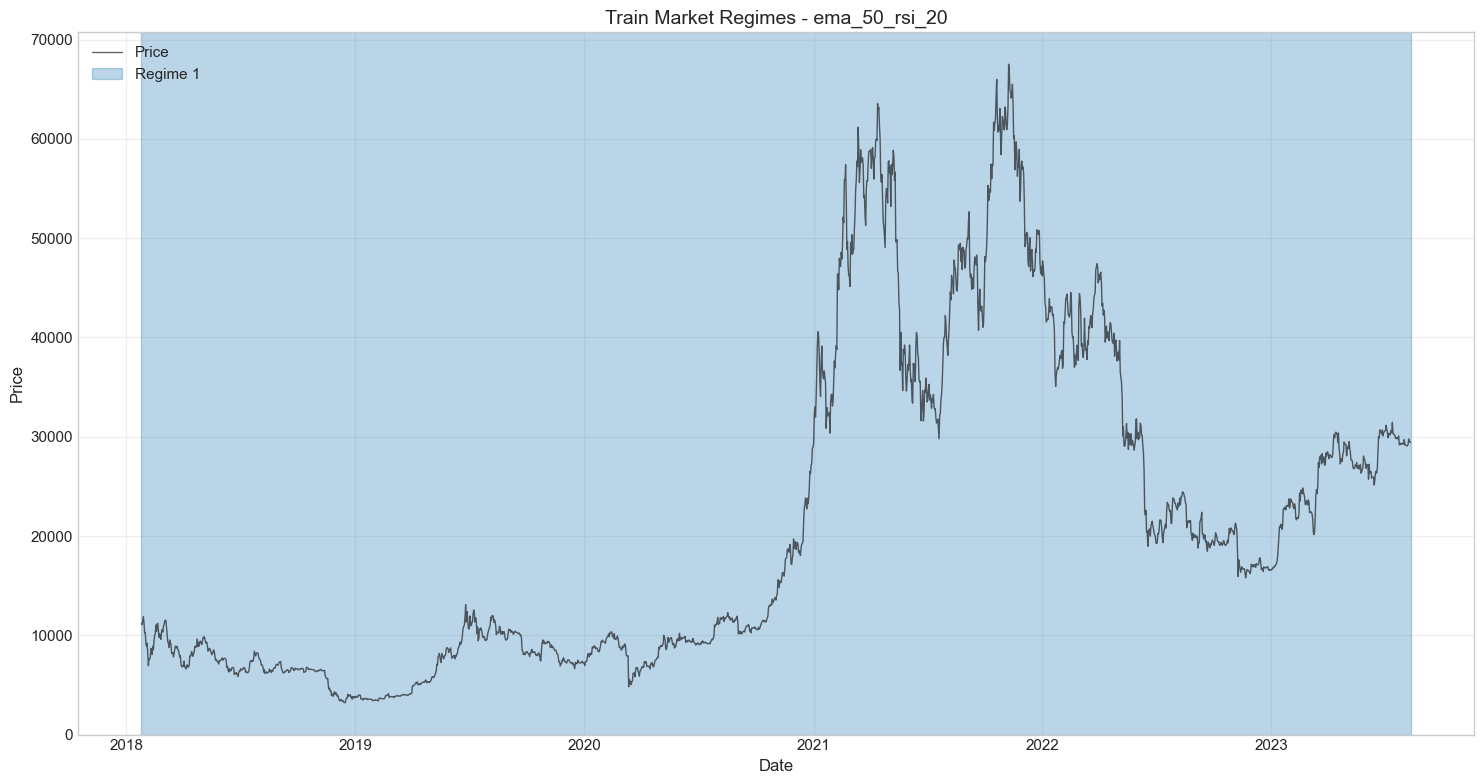

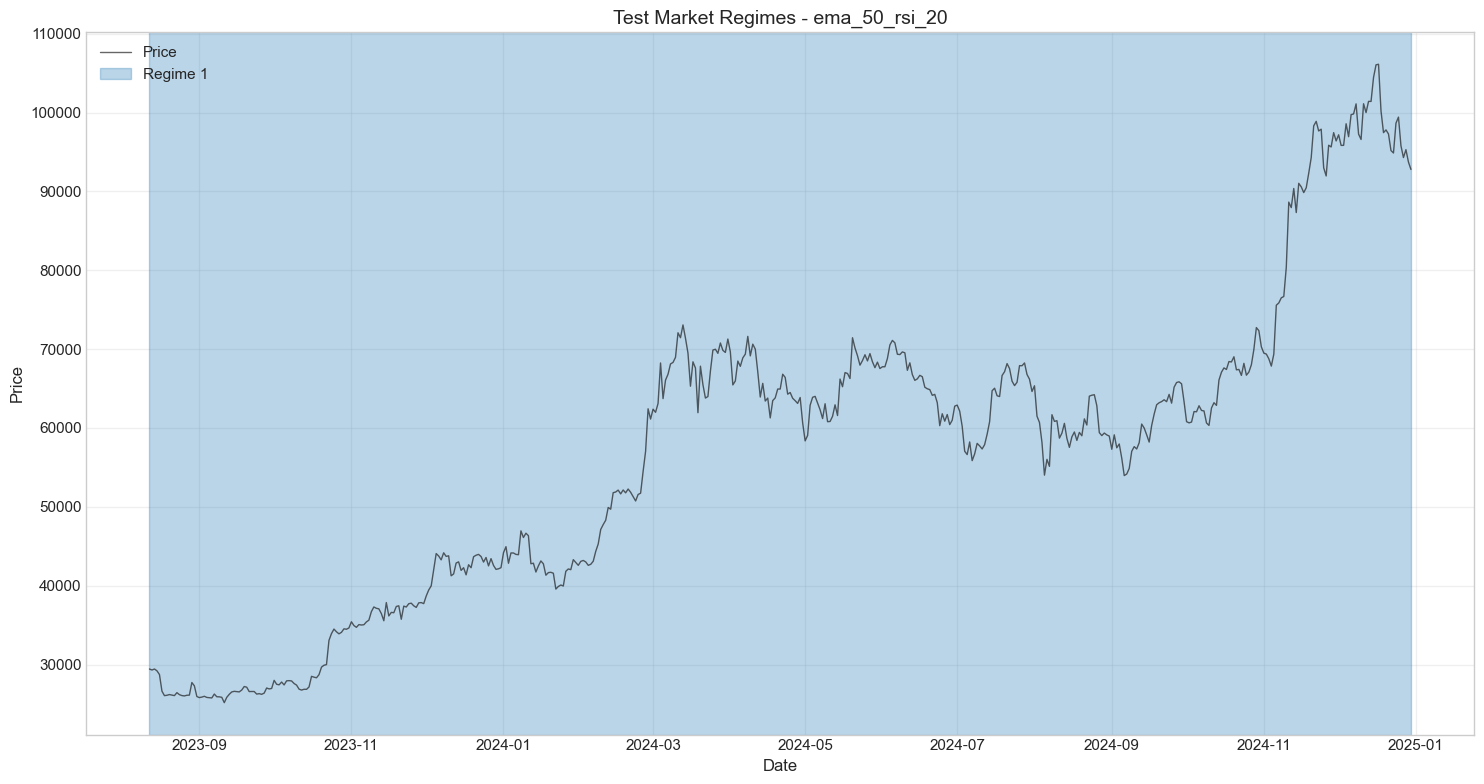


Regime Statistics:
          Mean  Median     Std    Min     Max  Count  Mean_Pct  Std_Pct  \
Regime                                                                    
1       0.0012  0.0004  0.0372 -0.395  0.1954   2025    0.1184   3.7225   

        Percentage  
Regime              
1            100.0  


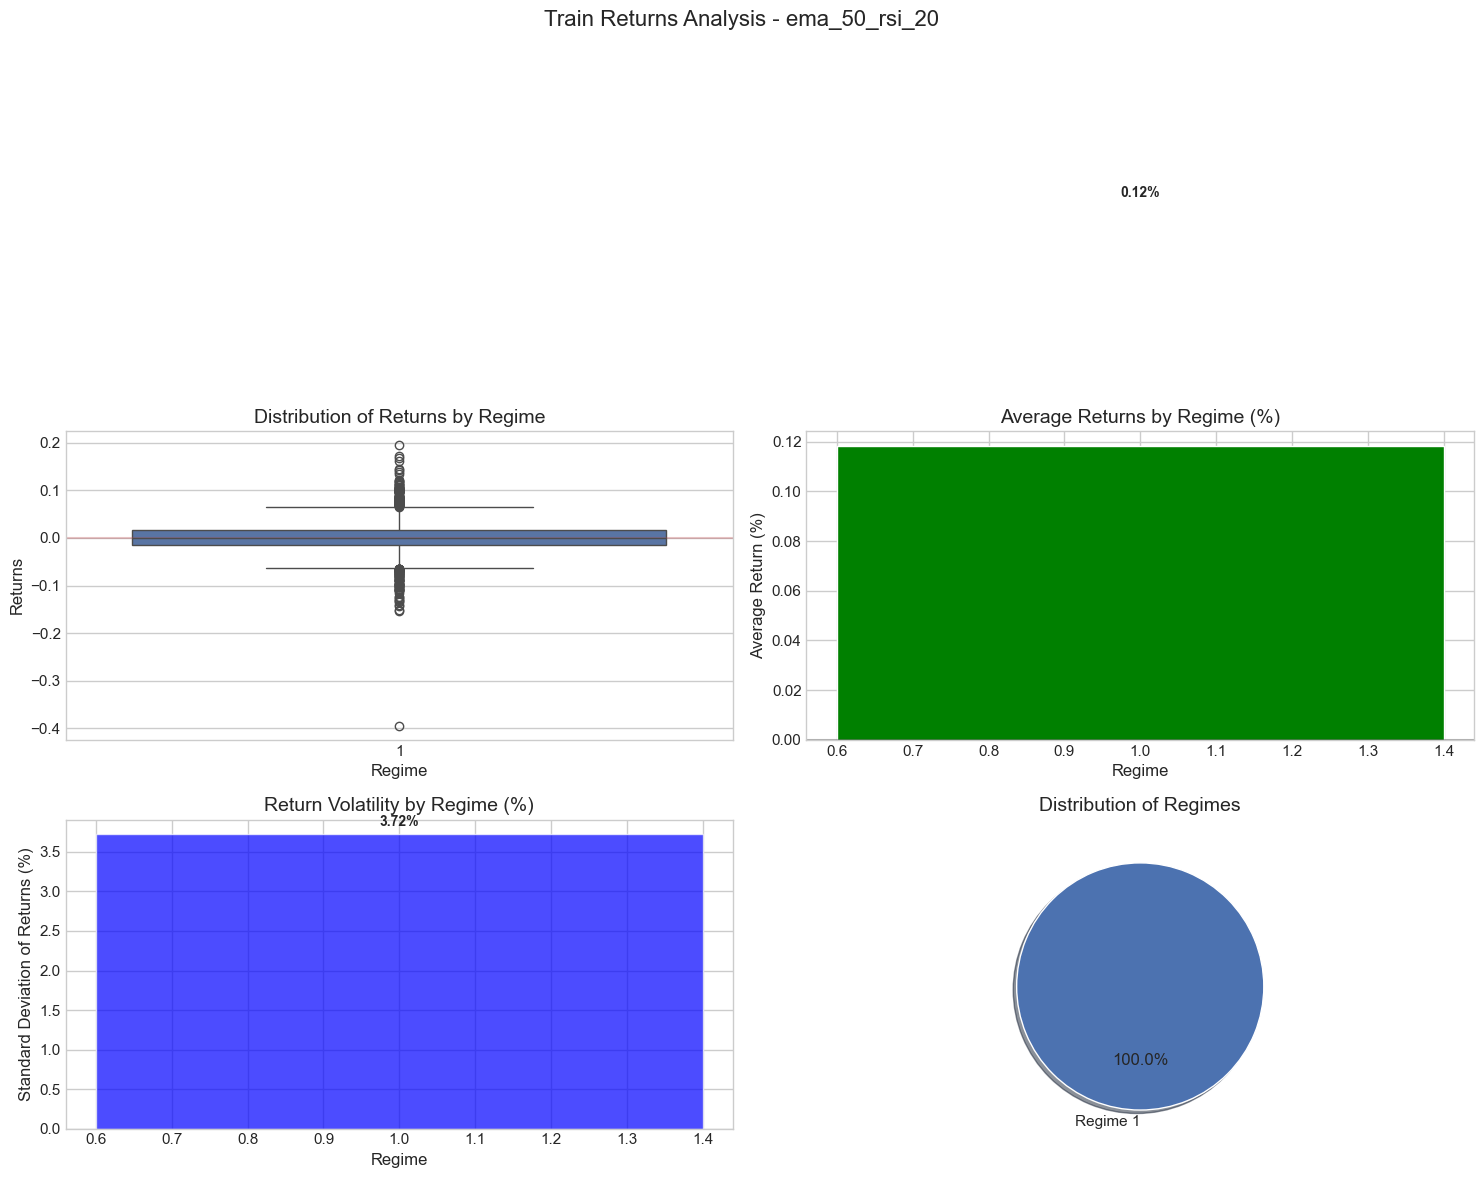


Regime Statistics:
          Mean  Median     Std     Min     Max  Count  Mean_Pct  Std_Pct  \
Regime                                                                     
1       0.0026  0.0009  0.0262 -0.0839  0.1188    507    0.2608   2.6226   

        Percentage  
Regime              
1            100.0  


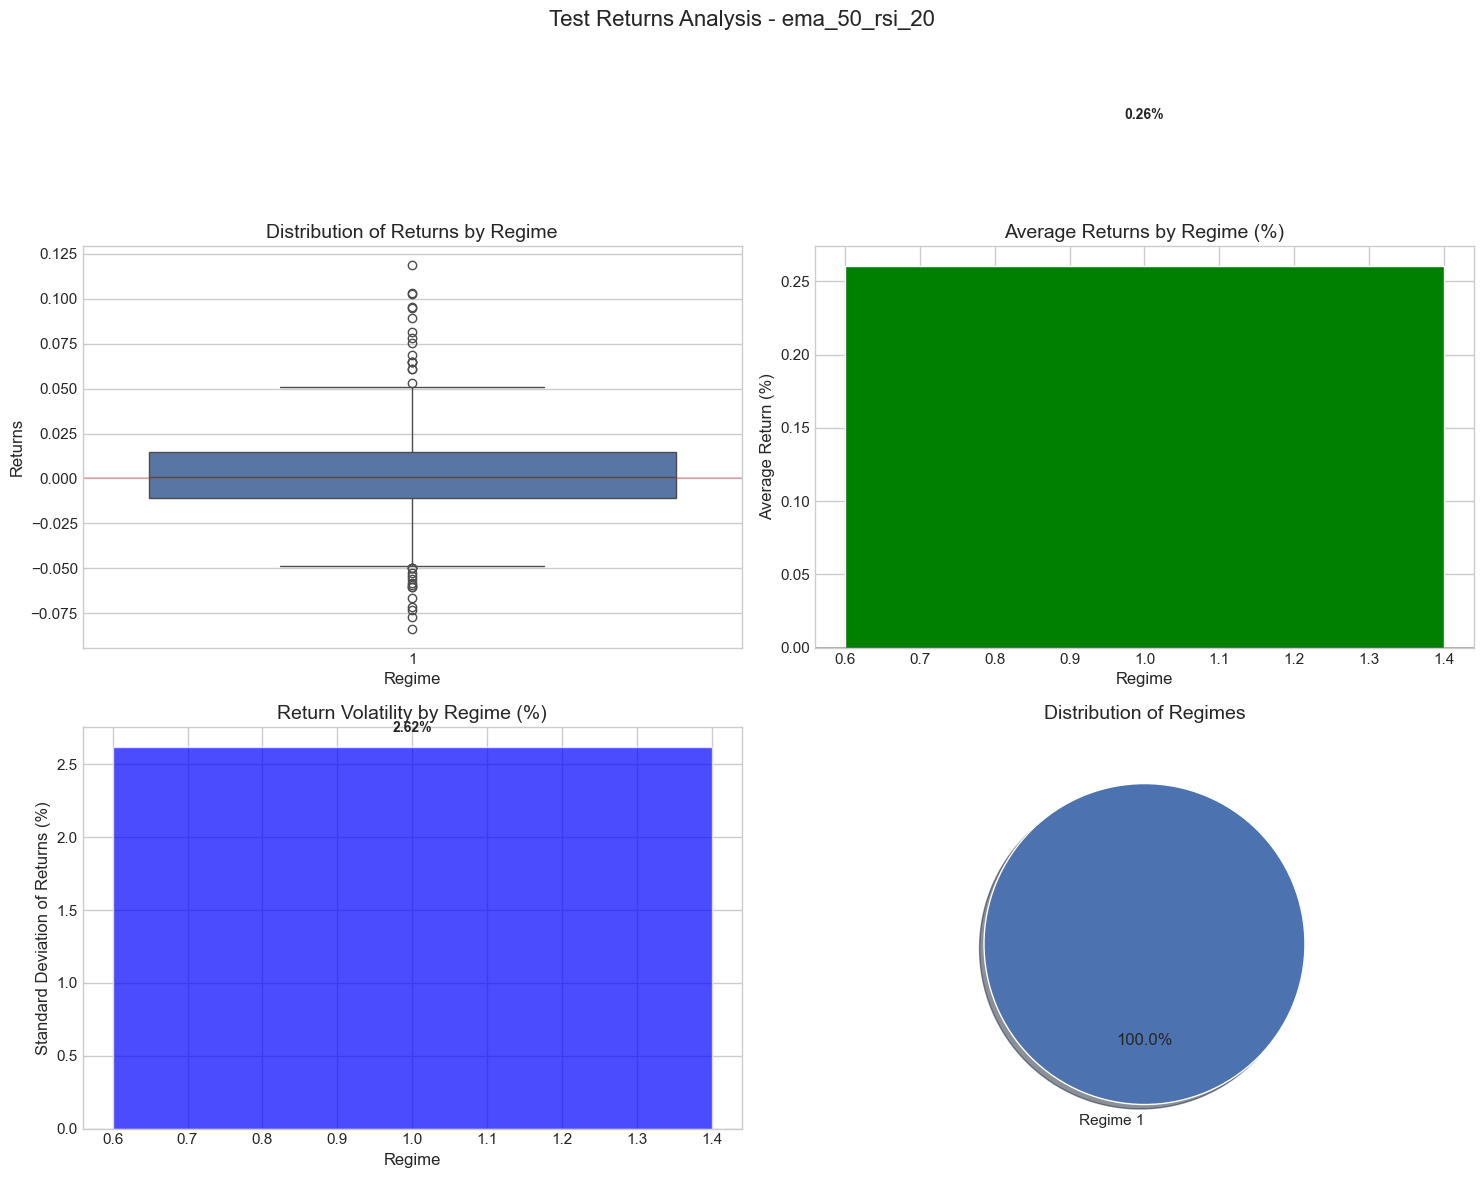

Successfully evaluated model DNNHMM_ema_50_rsi_20_0

Evaluating model: DNNHMM_original_rsi_20_1


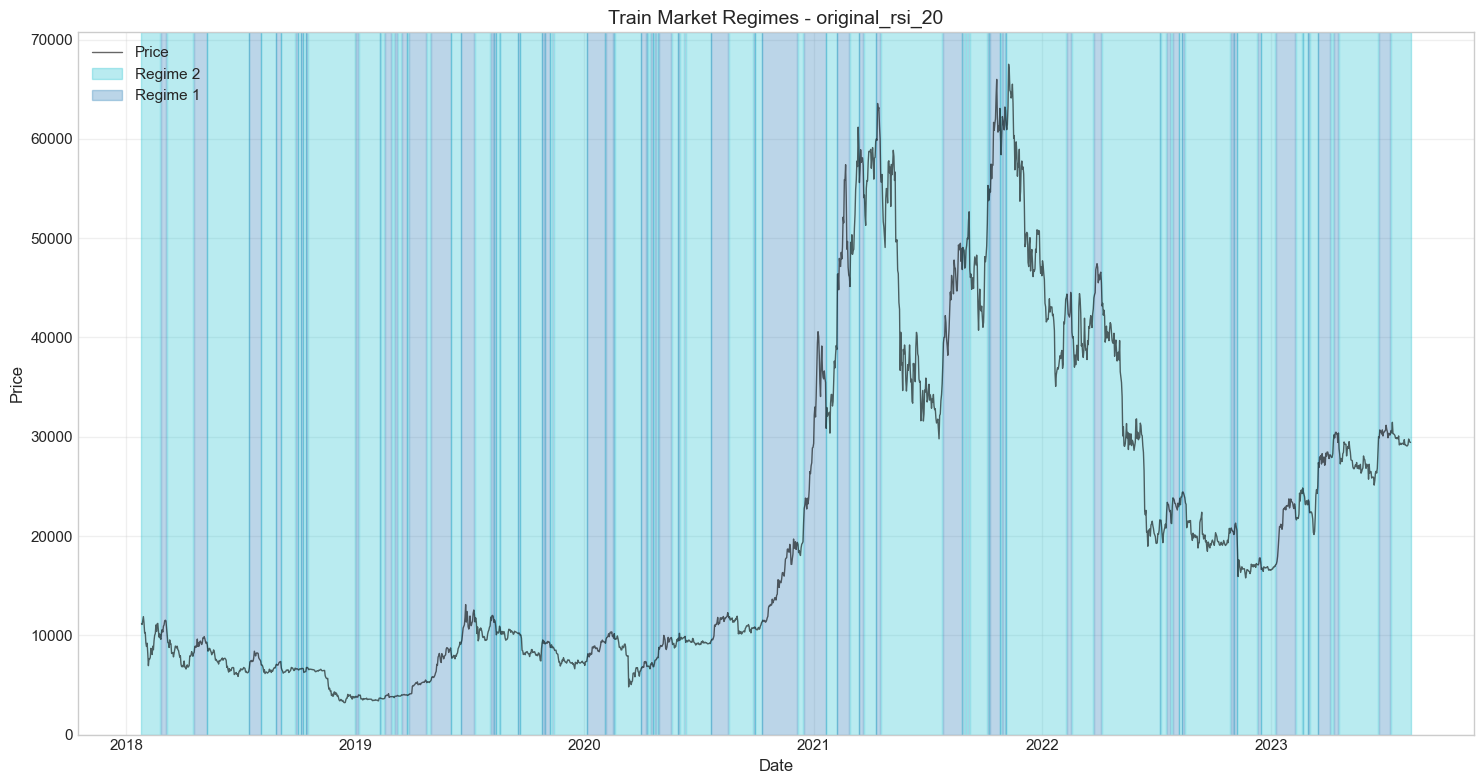

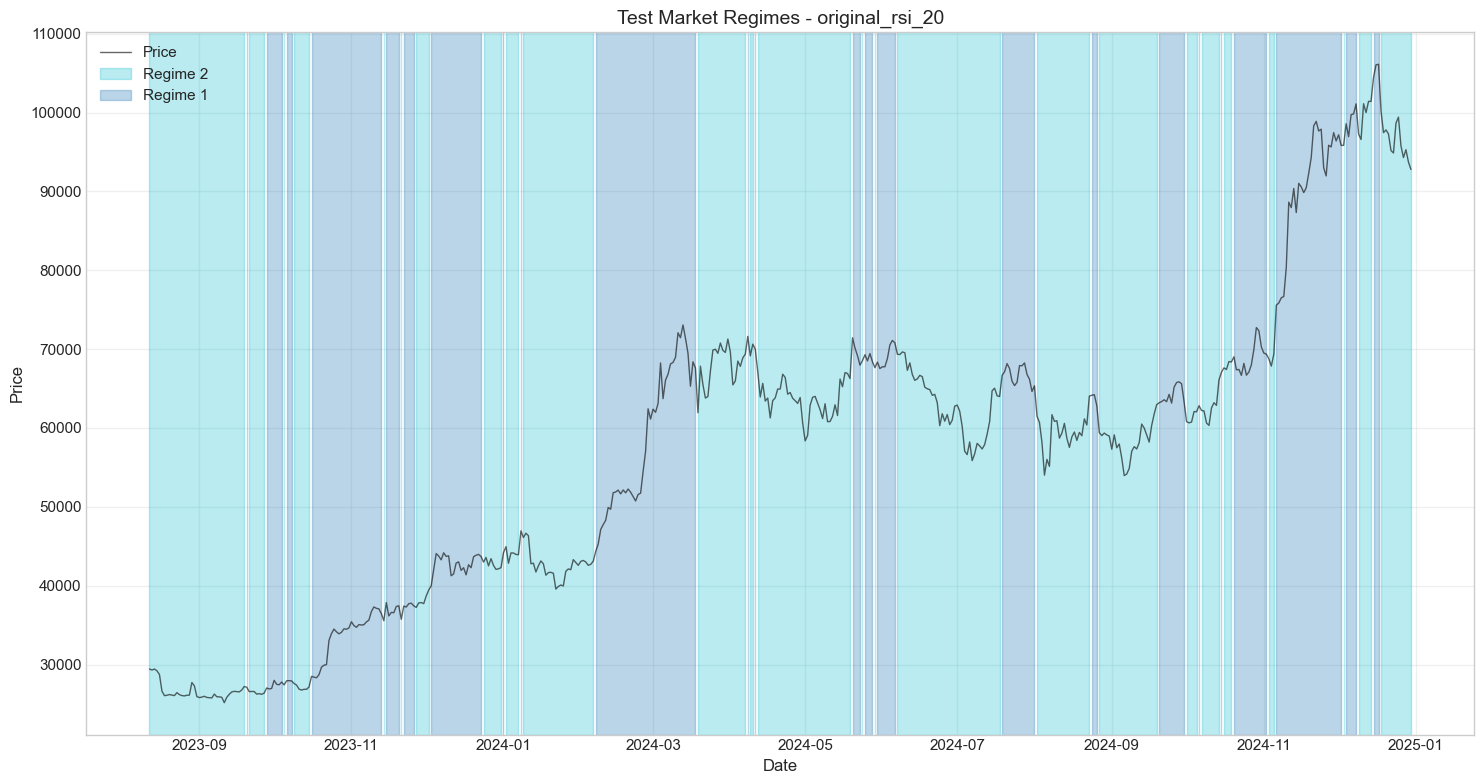


Regime Statistics:
          Mean  Median     Std     Min     Max  Count  Mean_Pct  Std_Pct  \
Regime                                                                     
1       0.0099  0.0050  0.0343 -0.1347  0.1954    652    0.9924   3.4327   
2      -0.0030 -0.0012  0.0378 -0.3950  0.1676   1373   -0.2967   3.7836   

        Percentage  
Regime              
1          32.1975  
2          67.8025  


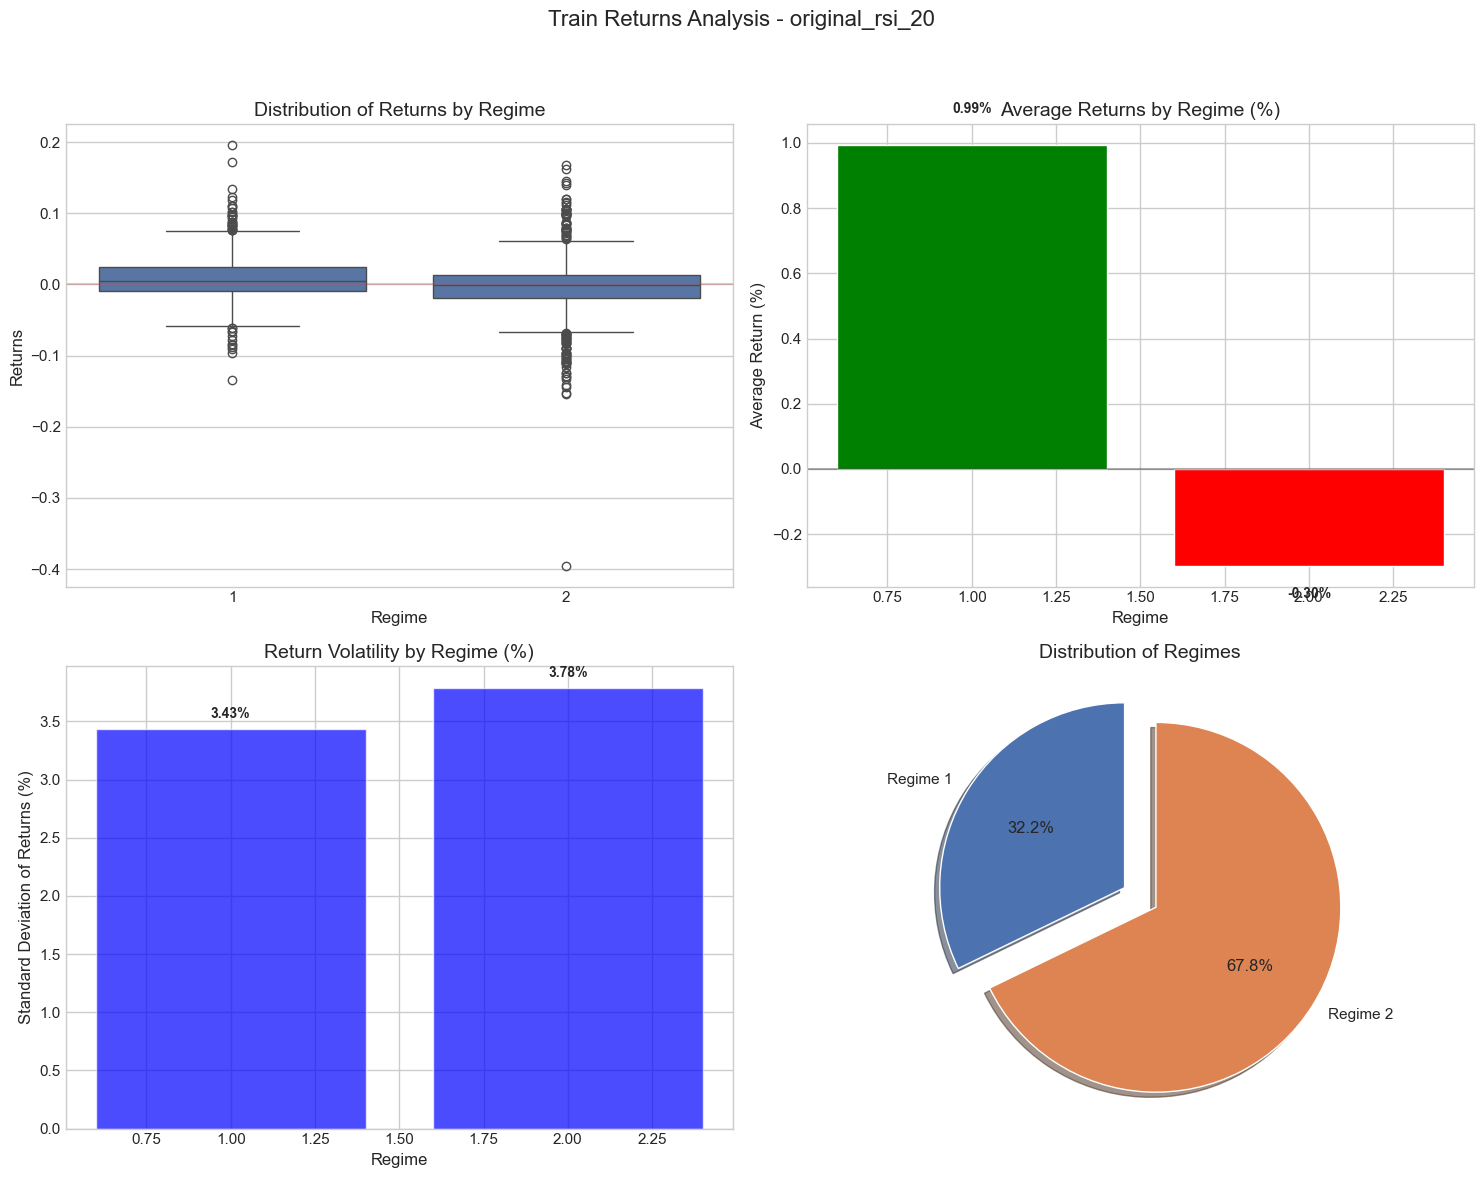


Regime Statistics:
          Mean  Median     Std     Min     Max  Count  Mean_Pct  Std_Pct  \
Regime                                                                     
1       0.0083  0.0042  0.0259 -0.0663  0.1030    212    0.8316   2.5904   
2      -0.0015 -0.0015  0.0257 -0.0839  0.1188    295   -0.1495   2.5725   

        Percentage  
Regime              
1          41.8146  
2          58.1854  


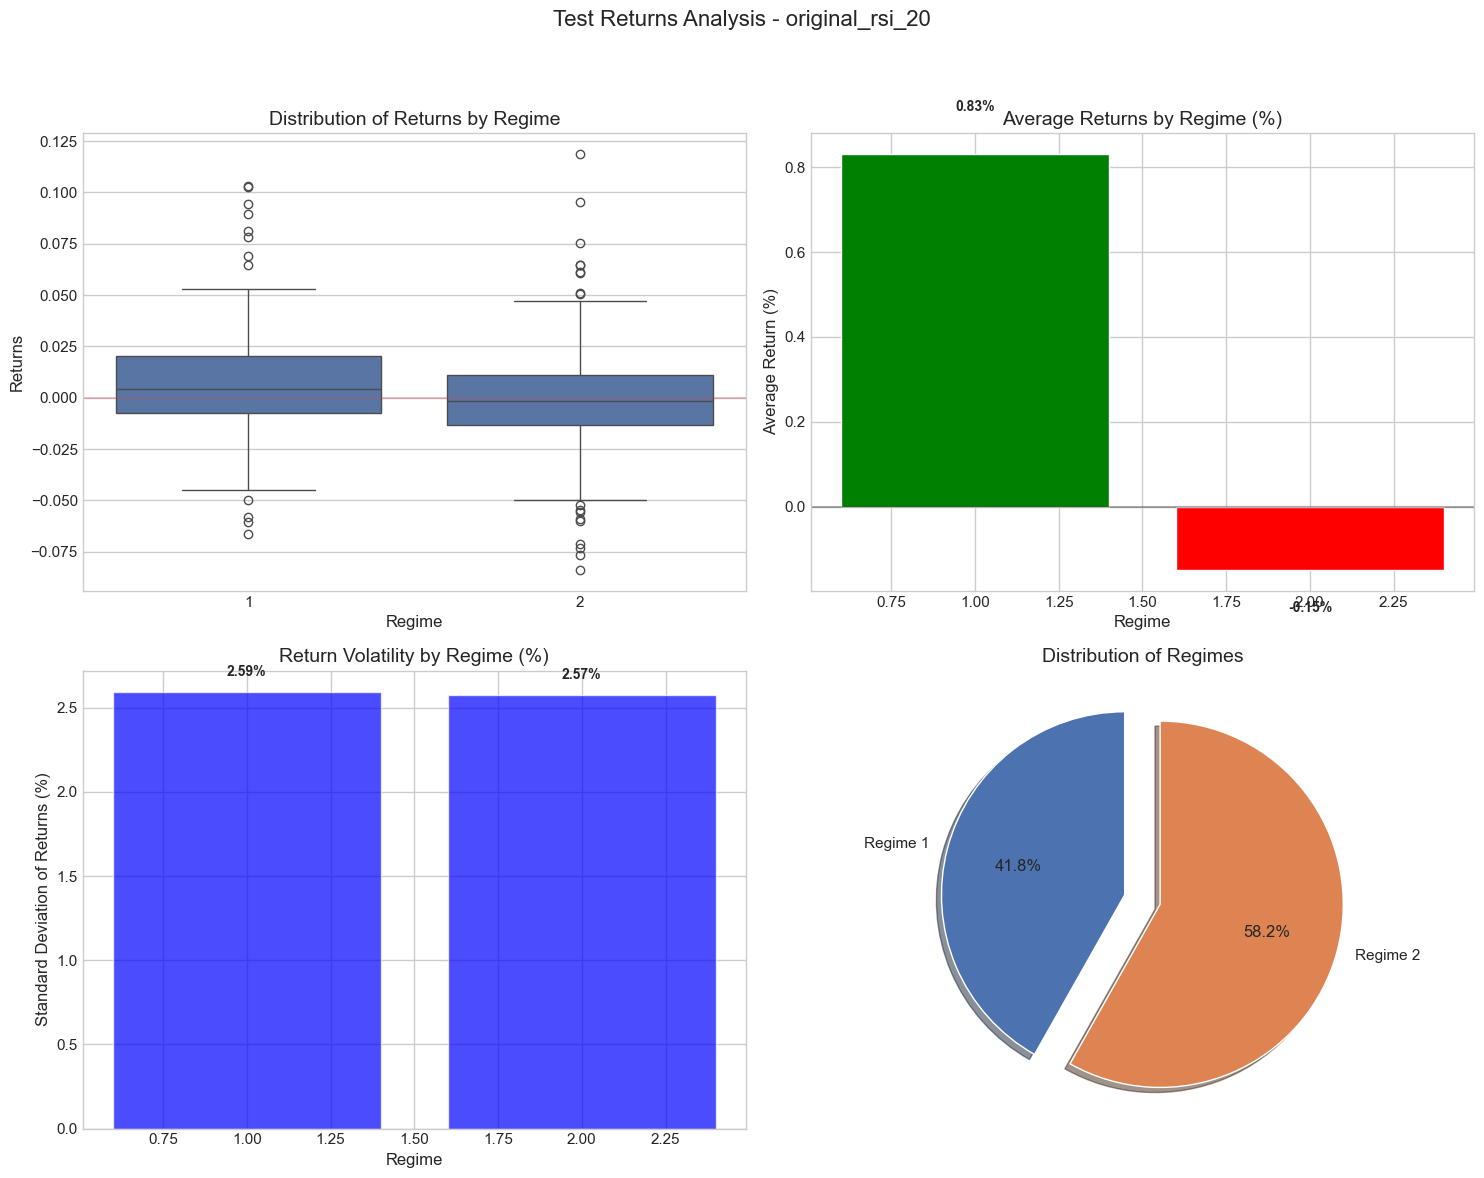

Successfully evaluated model DNNHMM_original_rsi_20_1

Top 2 models by silhouette score:
  original_rsi_20: 0.2733
  Train transitions: 126, Test transitions: 48
  Train plot: dnn_hmm_output/DNNHMM_original_rsi_20_1_TRAIN_regimes.png
  Test plot: dnn_hmm_output/DNNHMM_original_rsi_20_1_TEST_regimes.png

  ema_50_rsi_20: 0.0000
  Train transitions: 0, Test transitions: 0
  Train plot: dnn_hmm_output/DNNHMM_ema_50_rsi_20_0_TRAIN_regimes.png
  Test plot: dnn_hmm_output/DNNHMM_ema_50_rsi_20_0_TEST_regimes.png


Top Model: original_rsi_20 (Score: 0.2733)


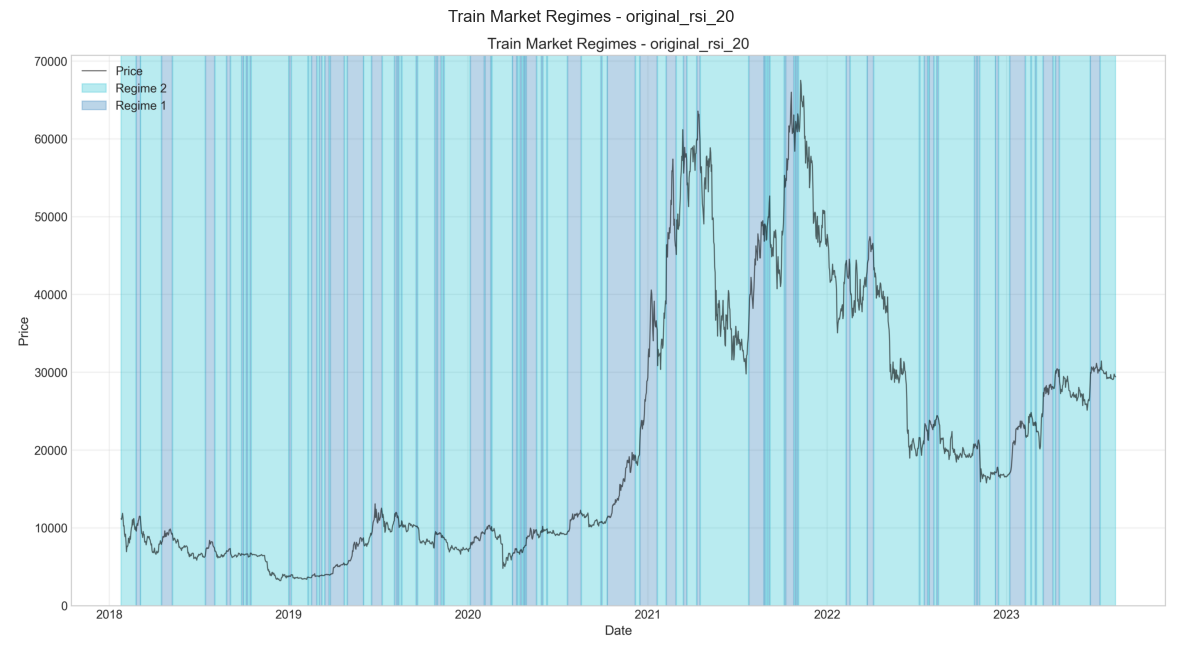

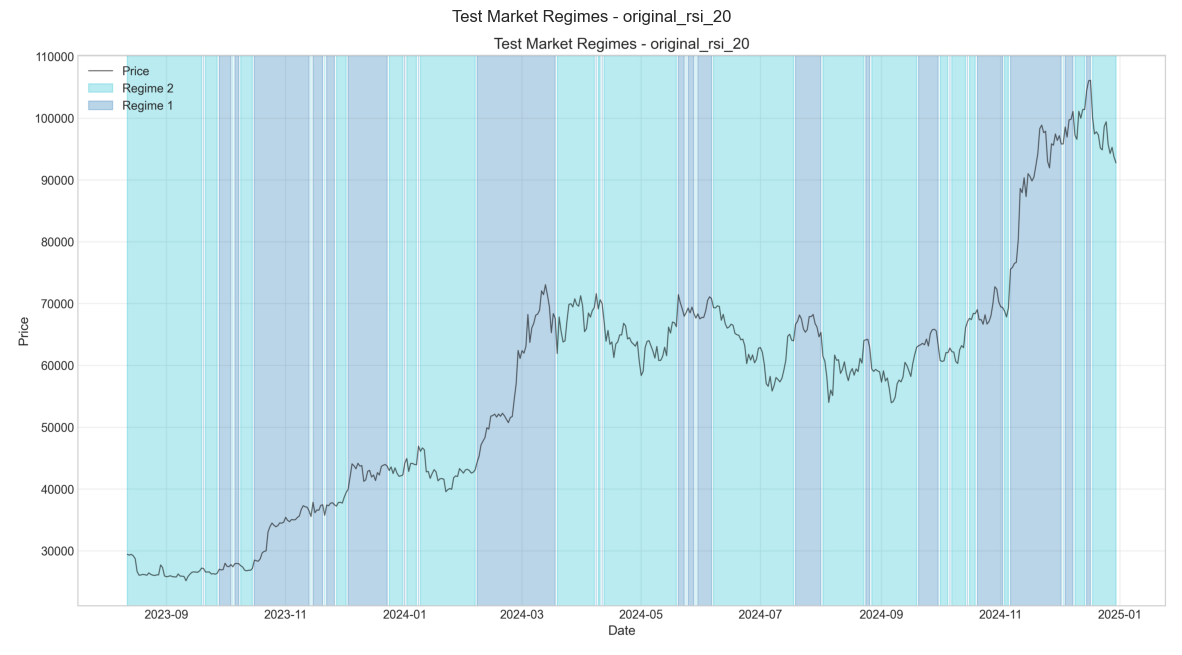

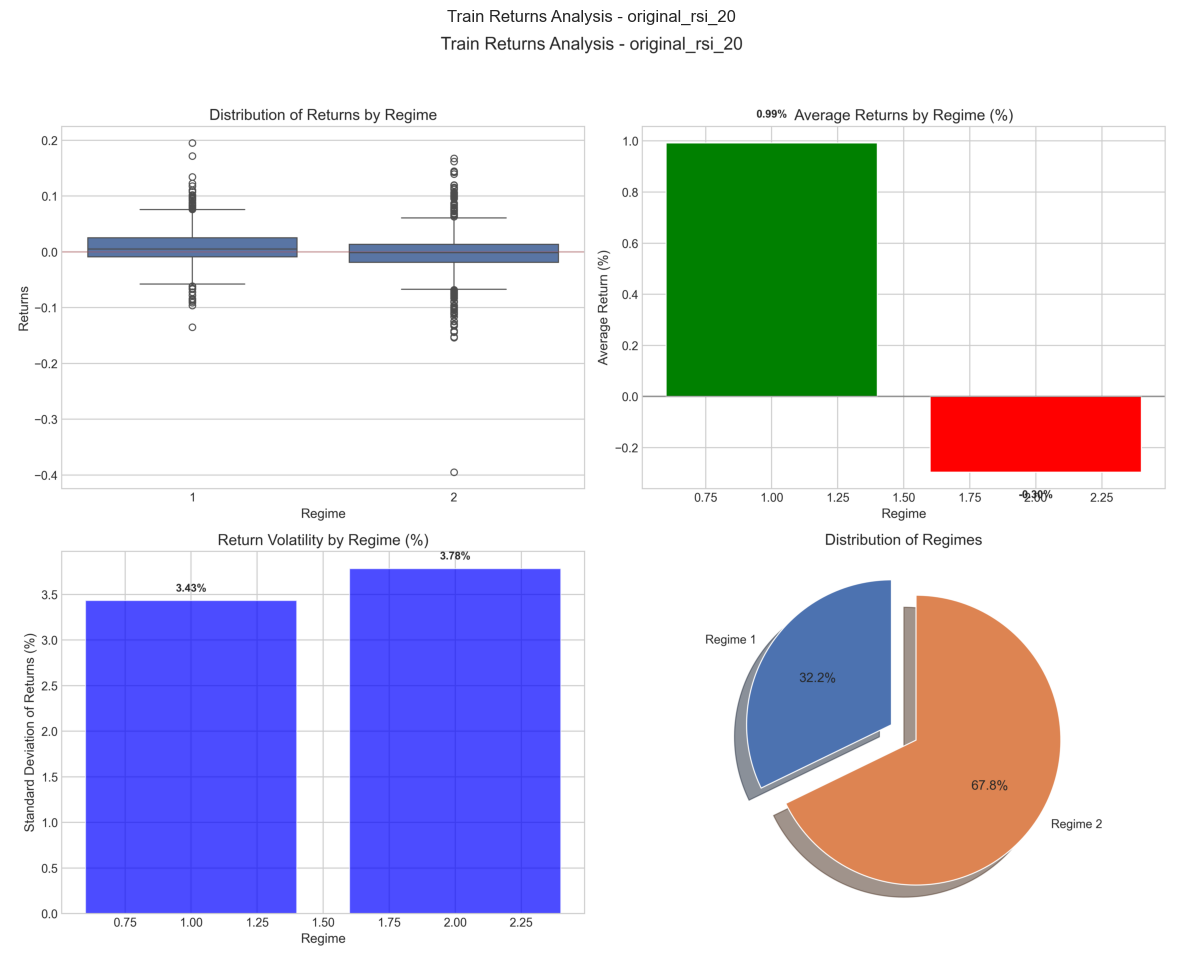

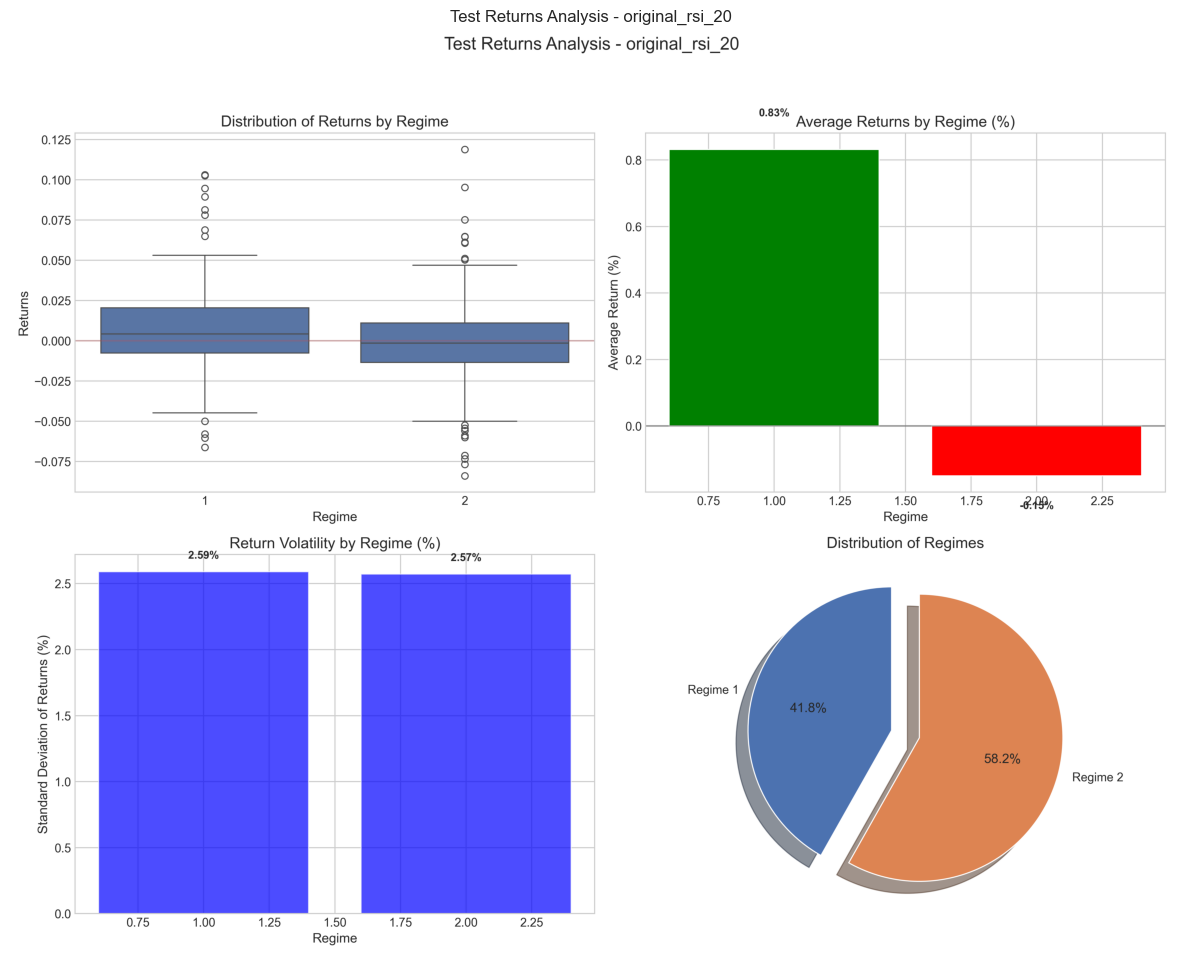


Top Model: ema_50_rsi_20 (Score: 0.0000)


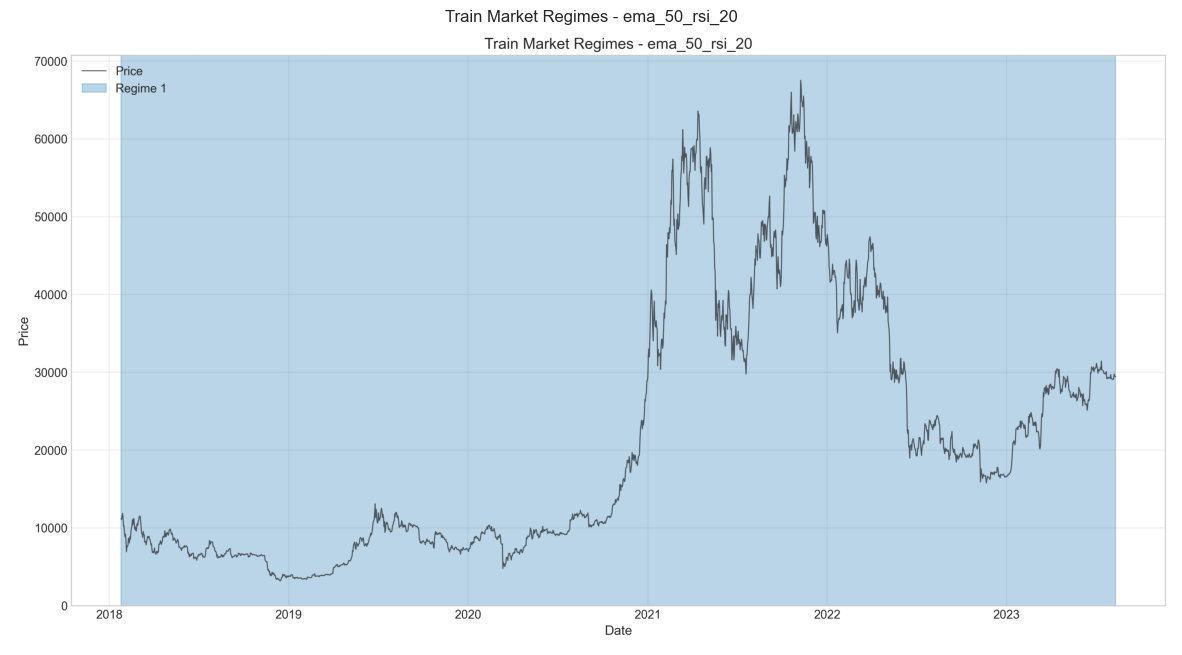

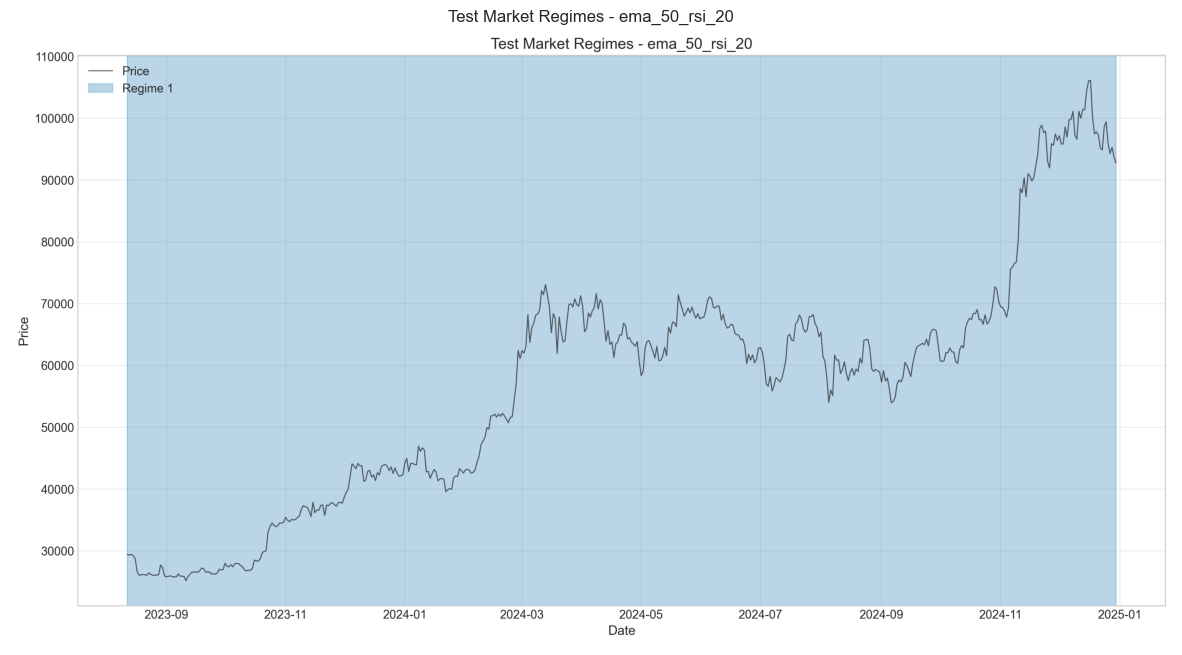

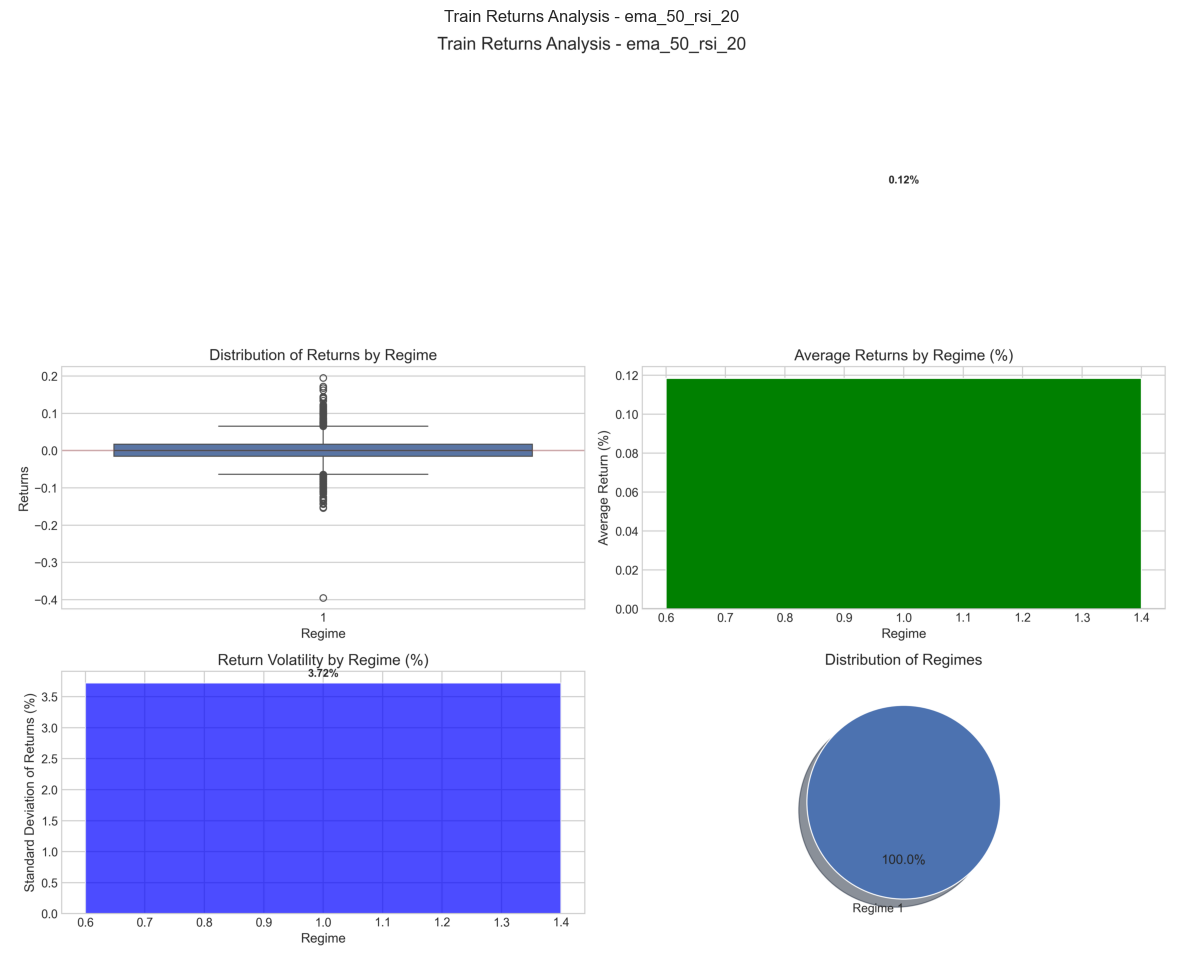

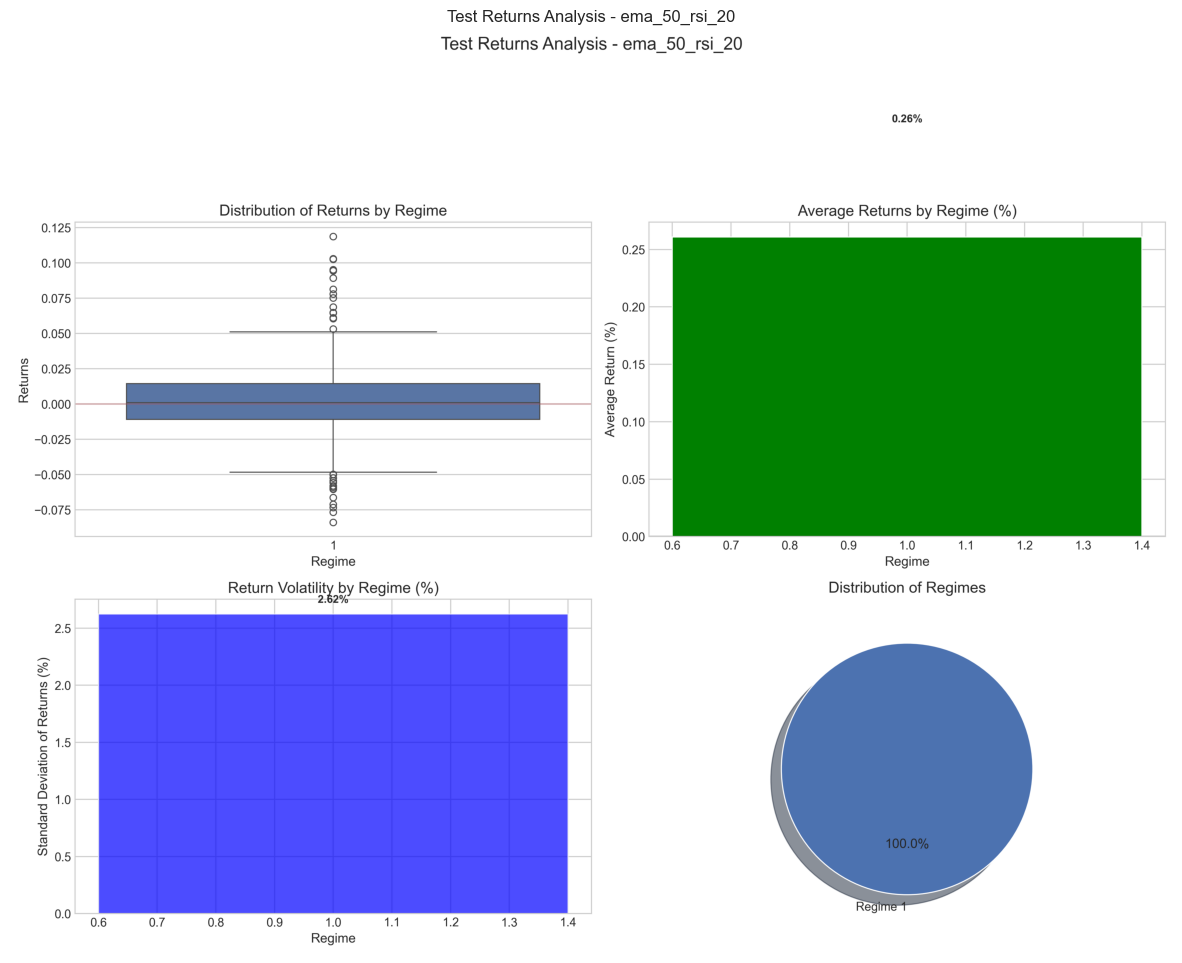

Exported 2 model results to dnn_hmm_individual_model_results.csv

ANALYSIS SUMMARY

Top 3 models by silhouette score:
Model: DNNHMM_original_rsi_20_1
  Group: unknown
  Features: 1
  Silhouette Score: 0.2733
  Log-Likelihood: -17299.603515625
  Regime Transitions: 48
  Transition Rate: 0.0949

Model: DNNHMM_ema_50_rsi_20_0
  Group: unknown
  Features: 1
  Silhouette Score: 0.0000
  Log-Likelihood: -41121.57421875
  Regime Transitions: 0
  Transition Rate: 0.0000


Check the 'dnn_hmm_output' folder for visualization of market regimes and returns analysis.

Full results have been exported to 'dnn_hmm_model_results.csv'.


In [9]:
# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Calculate returns (if not already available)
# Using pct_change is often appropriate for price data
if 'returns' not in locals():
    returns = price.pct_change().fillna(0)
    train_returns = returns.iloc[:train_size]
    test_returns = returns.iloc[train_size:]

# Print basic info about the data
print(f"Training data shape: {train_rsi.shape}")
print(f"Testing data shape: {test_rsi.shape}")
print(f"Available RSI indicators: {len(train_rsi.columns)}")

# Run the main analysis with 3 market regimes
model_results = main_individual_models_with_visualization(
    train_rsi=train_rsi,
    test_rsi=test_rsi,
    train_price=train_price,
    test_price=test_price,
    train_returns=train_returns,
    test_returns=test_returns,
    n_states=3  # Commonly used for market regimes (bull, bear, sideways)
)

# Display a summary of the results
print("\n" + "="*50)
print("ANALYSIS SUMMARY")
print("="*50)

# Get best models by silhouette score
best_models = get_best_models(model_results, metric='silhouette_score', top_n=3)

print("\nTop 3 models by silhouette score:")
for model_id, score in best_models:
    model_info = model_results[model_id]
    group_name = model_info.get('group_name', 'unknown')
    feature_count = len(model_info.get('features', []))
    
    print(f"Model: {model_id}")
    print(f"  Group: {group_name}")
    print(f"  Features: {feature_count}")
    print(f"  Silhouette Score: {score:.4f}")
    print(f"  Log-Likelihood: {model_info.get('log_likelihood', 'N/A')}")
    
    # Count regime transitions
    regimes = model_info.get('test_regimes', [])
    if len(regimes) > 0:
        transitions = sum(1 for i in range(1, len(regimes)) if regimes[i] != regimes[i-1])
        print(f"  Regime Transitions: {transitions}")
        print(f"  Transition Rate: {transitions/(len(regimes)-1):.4f}")
    
    print()

print("\nCheck the 'dnn_hmm_output' folder for visualization of market regimes and returns analysis.")
print("\nFull results have been exported to 'dnn_hmm_model_results.csv'.")

### Conclusion
DNN-HMM performs best for houly data using the EMA50_RSI20 index and is able to detect 3 regimes with ss ranging from 0.82 till 0.87. This makes sense since NNs need lots of data for traing. When it comes to daily data our model dosent perform as well. For daily data a standard hmm performs better, but not for the EMA50_RSI20 index. For daily data the rsi20 performs well with a ss = 0.3 or the fear and greed index with an ss = 0.5. The results where calculated after multiple runs.

There is always the fear of overfitting, especially with high frequency data. To combat that we could combine both models, the DNN-HMM for hourly data and the Standard-HMM for daily data. 